## Data Preprocessing and Exploration

In [79]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
%pip install xgboost shap
%pip install keras
import xgboost as xgb
from xgboost import XGBRegressor
import shap, time
from sklearn.neural_network import MLPRegressor


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\shire\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\shire\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Load the ecommerce behaviour dataset

df = pd.read_csv('data/2019-Oct.csv')
print("First five rows of the dataset:")
df.head()

First five rows of the dataset:


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [3]:
# Dataset Overview
print("Shape:", df.shape)
print("\n")

# Detailed Info
print("Dataset Info:")
print("="*50)
df.info()
print("\n")

# Statistical Summary
print("Statistical Description:")
print("="*50)
with pd.option_context('display.max_columns', None, 
                        'display.width', None,
                        'display.float_format', '{:.2f}'.format):
    print(df.describe(include='all'))

Shape: (42448764, 9)


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42448764 entries, 0 to 42448763
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 2.8+ GB


Statistical Description:
                     event_time event_type  product_id            category_id  \
count                  42448764   42448764 42448764.00            42448764.00   
unique                  2621538          3         NaN                    NaN   
top     2019-10-15 08:52:00 UTC       view         NaN                    NaN   
freq                        116   40779399         NaN                    NaN   
mean                        NaN        NaN 1054

### Exploratory Data Analysis

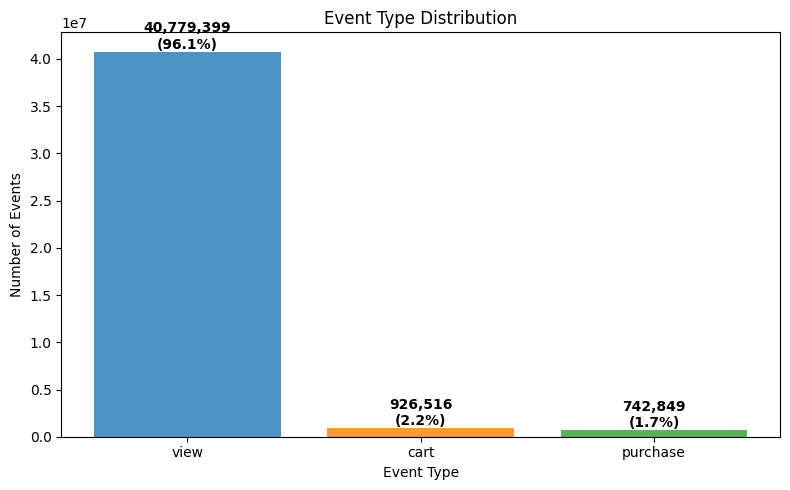

In [4]:
# Visualization of event type distribution
# Bar chart showing count and percentage of each event type (view, cart, purchase)

plt.figure(figsize=(8, 5))
event_counts = df['event_type'].value_counts()  # Count occurrences of each event type
bars = plt.bar(event_counts.index, event_counts.values, 
               color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)

# Add count and percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:,}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

plt.title('Event Type Distribution')
plt.xlabel('Event Type')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

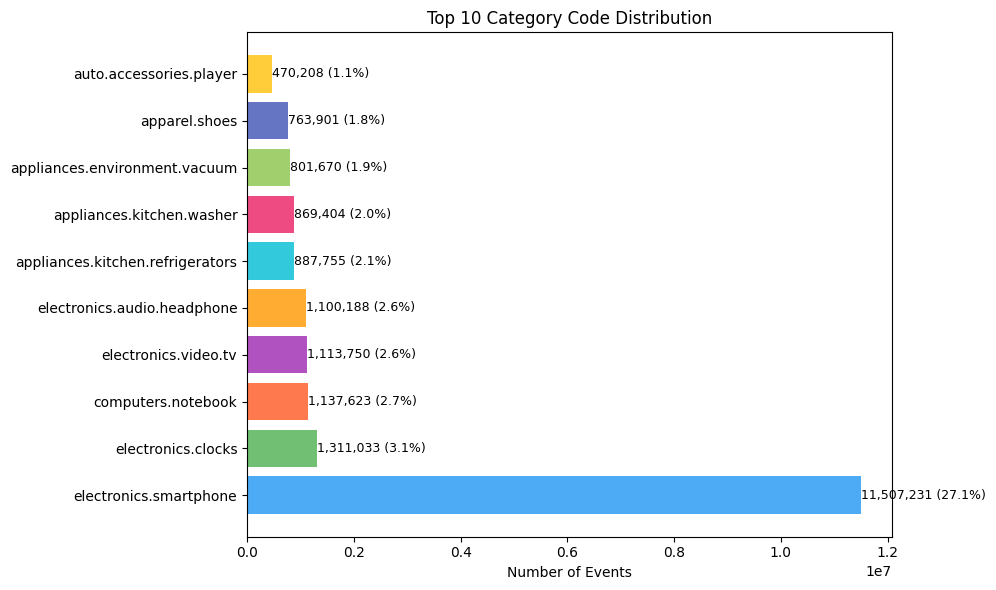

In [5]:
# Visualization of top 10 category_code values
# Horizontal bar chart — best for long category names, easy rank comparison

top_categories = df['category_code'].value_counts().nlargest(10)  # Get top 10 categories by frequency

# Define distinct colors for each bar
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800',
          '#00BCD4', '#E91E63', '#8BC34A', '#3F51B5', '#FFC107']

plt.figure(figsize=(10, 6))
bars = plt.barh(top_categories.index, top_categories.values, color=colors, alpha=0.8)

# Add count and percentage labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2.,
             f'{width:,} ({width/len(df)*100:.1f}%)',
             ha='left', va='center', fontsize=9)

plt.title('Top 10 Category Code Distribution')
plt.xlabel('Number of Events')
plt.tight_layout()
plt.show()

C:\Users\shire\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


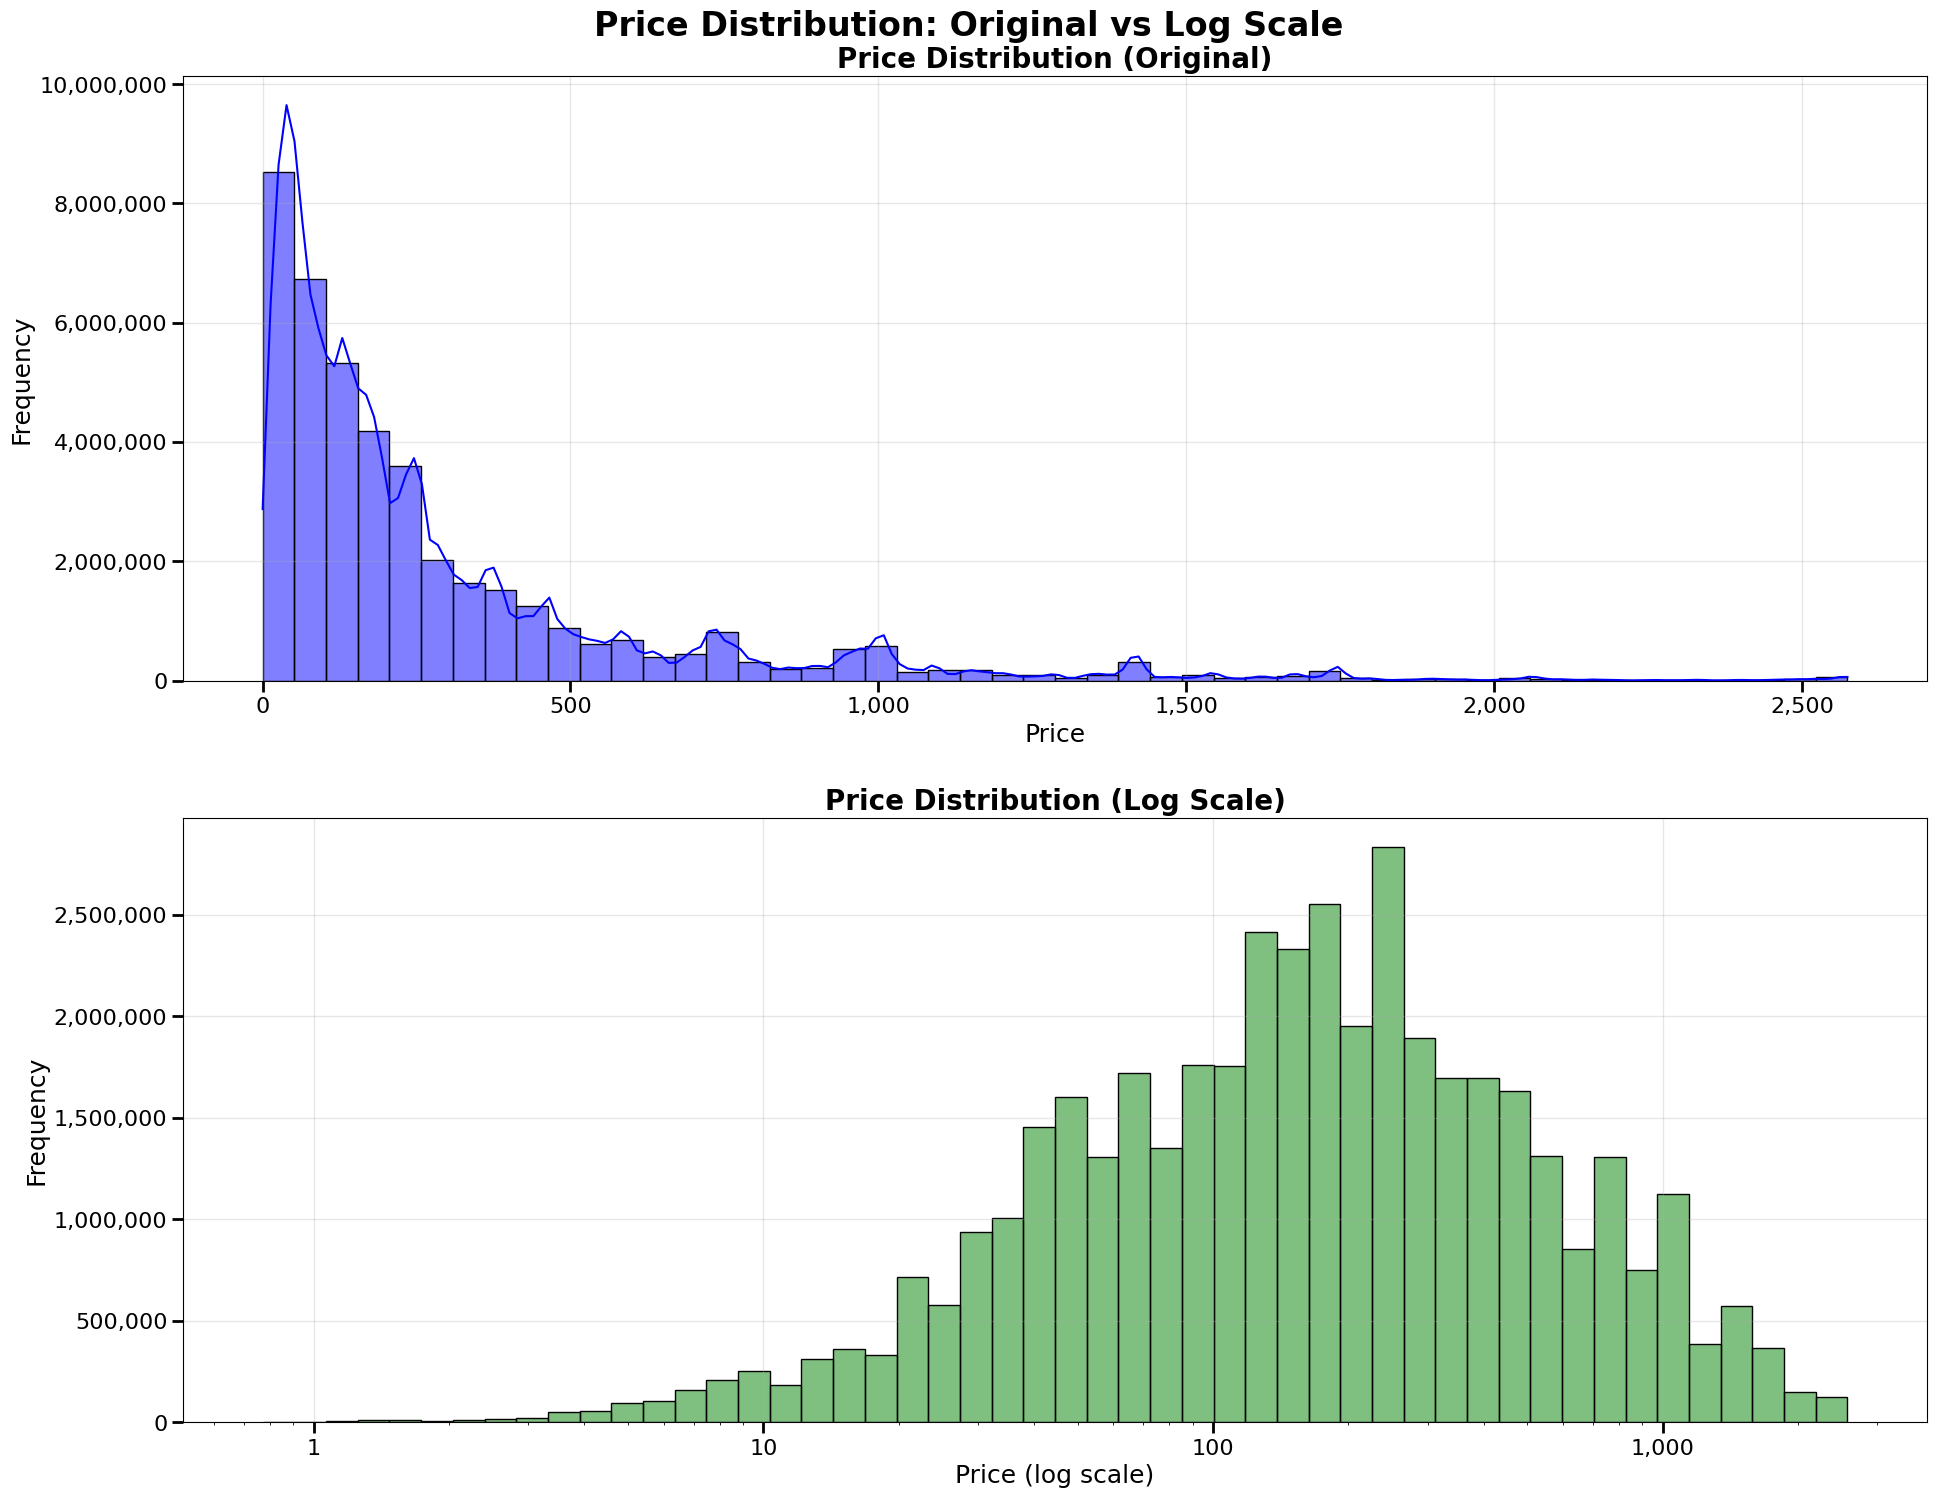

In [6]:
# Maximum visibility for axes values
fig, axes = plt.subplots(2, 1, figsize=(20, 16))

# Disable scientific notation for better readability
plt.rcParams['axes.formatter.useoffset'] = False

# Top plot
sns.histplot(df['price'], bins=50, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Price Distribution (Original)', fontsize=20, fontweight='bold')
axes[0].set_xlabel('Price', fontsize=18)
axes[0].set_ylabel('Frequency', fontsize=18)
axes[0].tick_params(axis='both', which='major', labelsize=16, width=2, length=8)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))  # Format x-axis
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))  # Format y-axis
axes[0].grid(True, alpha=0.3, linewidth=1)

# Bottom plot
sns.histplot(df['price'], bins=50, kde=True, log_scale=True, color='green', ax=axes[1])
axes[1].set_title('Price Distribution (Log Scale)', fontsize=20, fontweight='bold')
axes[1].set_xlabel('Price (log scale)', fontsize=18)
axes[1].set_ylabel('Frequency', fontsize=18)
axes[1].tick_params(axis='both', which='major', labelsize=16, width=2, length=8)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))  # Format x-axis
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))  # Format y-axis
axes[1].grid(True, alpha=0.3, linewidth=1)

plt.suptitle('Price Distribution: Original vs Log Scale', fontsize=24, fontweight='bold', y=0.95)
plt.tight_layout(pad=3.0)
plt.show()

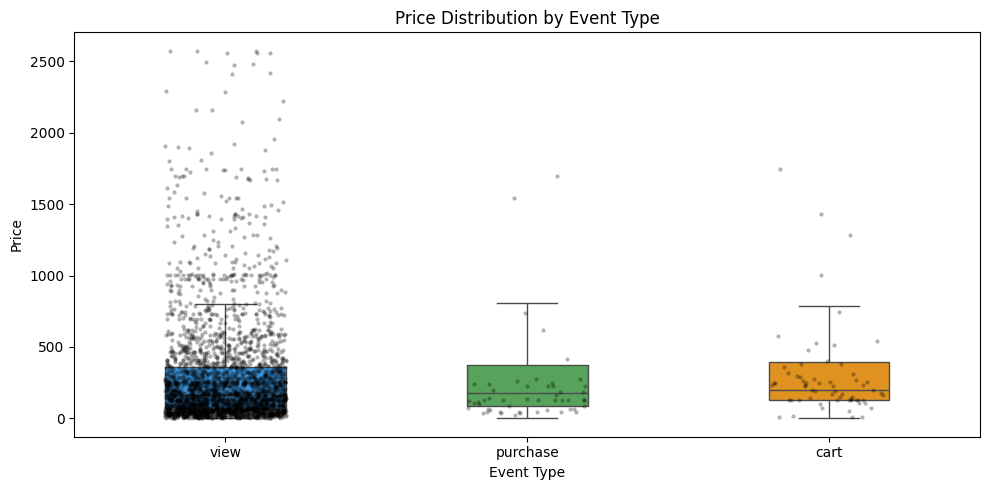

In [7]:
# Scatter Plot: Price vs Event Type
# Box plot overlaid with stripplot — combines summary statistics with individual data points
# Shows median, IQR, outliers AND raw distribution simultaneously

plt.figure(figsize=(10, 5))

# Base layer: box plot — hue set explicitly to suppress FutureWarning
sns.boxplot(x='event_type', y='price', data=df,
            hue='event_type',  # Explicitly assign hue to match x variable
            palette={'view': '#2196F3', 'cart': '#FF9800', 'purchase': '#4CAF50'},
            width=0.4, fliersize=0,  # fliersize=0 hides outlier dots from boxplot
            legend=False)  # Suppress legend since x-axis already labels event types

# Top layer: individual points sampled for readability
sns.stripplot(x='event_type', y='price', data=df.sample(3000),
              color='black', alpha=0.3, jitter=0.2, size=3)  # Black dots overlay for raw data points

plt.title('Price Distribution by Event Type')
plt.xlabel('Event Type')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

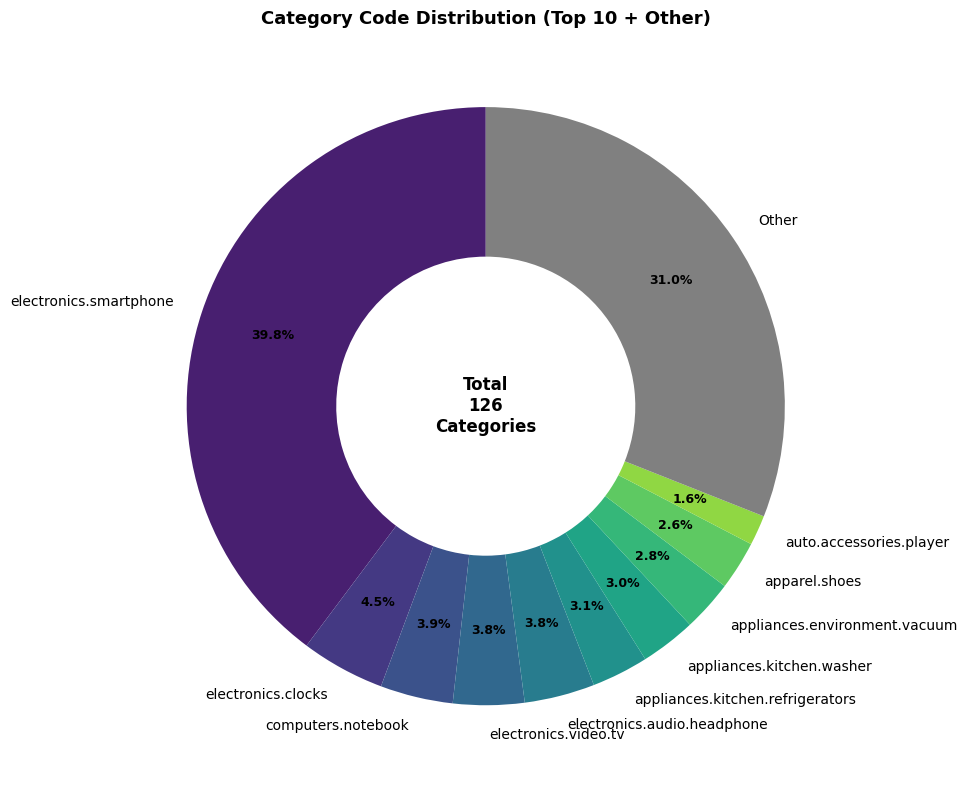

In [8]:
# Visualization of top 10 category_code values + Other
# Donut chart — cleaner than pie chart, centre space can display key insight

# Combine smaller categories into 'Other'
category_counts = df['category_code'].value_counts()
top_n = 10
top_categories = category_counts[:top_n].copy()  # Get top 10 categories
other_count = category_counts[top_n:].sum()       # Sum all remaining categories
top_categories['Other'] = other_count             # Add 'Other' as final slice

# Define distinct colors for each slice
colors = sns.color_palette('viridis', len(top_categories))
colors[-1] = (0.5, 0.5, 0.5)  # Set 'Other' slice to grey for visual distinction

plt.figure(figsize=(10, 8))

# Draw donut — wedgeprops width controls thickness (0=full circle, 1=no hole)
wedges, texts, autotexts = plt.pie(top_categories.values,
                                    labels=top_categories.index,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    colors=colors,
                                    wedgeprops=dict(width=0.5),  # Controls donut hole size
                                    pctdistance=0.75)            # Position percentage labels inside ring

# Style percentage labels for readability
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

# Add centre text showing total number of categories
plt.text(0, 0, f'Total\n{len(category_counts)}\nCategories',
         ha='center', va='center', fontsize=12, fontweight='bold')  # Centre label inside donut hole

plt.title('Category Code Distribution (Top 10 + Other)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

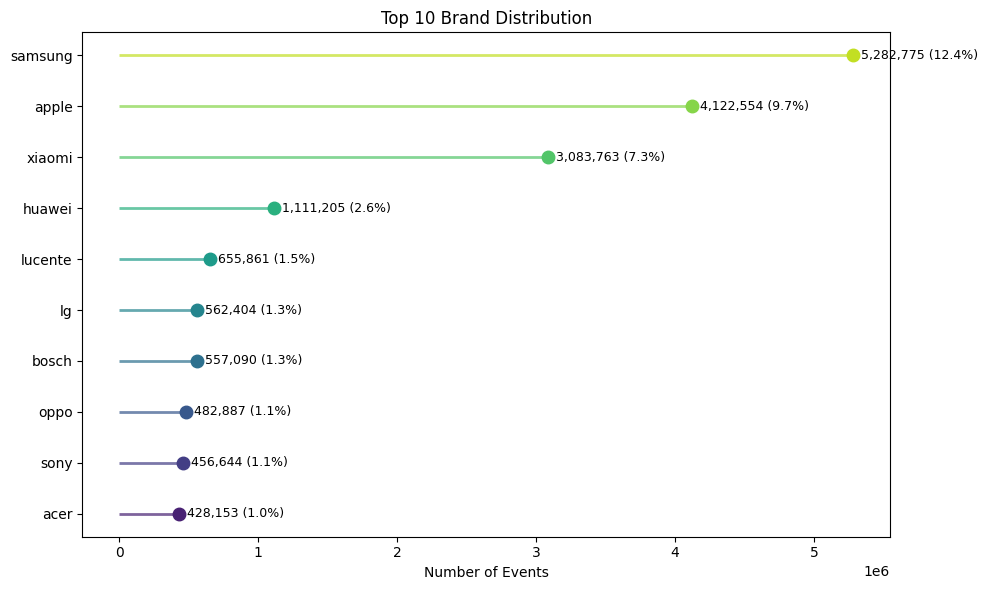

In [9]:
# Visualization of top 10 brands by interaction frequency
# Lollipop chart — modern clean alternative to bar chart, reduces visual clutter

# Get top 10 brands sorted ascending for readability
top_brands = df['brand'].value_counts().nlargest(10).sort_values()

colors = sns.color_palette('viridis', len(top_brands))

plt.figure(figsize=(10, 6))

# Draw horizontal lines from 0 to each brand's count
for i, (brand, val) in enumerate(zip(top_brands.index, top_brands.values)):
    plt.hlines(y=brand, xmin=0, xmax=val, color=colors[i], linewidth=2, alpha=0.7)

# Draw dot at the end of each line
for i, (brand, val) in enumerate(zip(top_brands.index, top_brands.values)):
    plt.plot(val, brand, 'o', color=colors[i], markersize=9)

# Add value labels next to each dot
for brand, val in zip(top_brands.index, top_brands.values):
    plt.text(val, brand, f'  {val:,} ({val/len(df)*100:.1f}%)',
             va='center', fontsize=9)

plt.title('Top 10 Brand Distribution')
plt.xlabel('Number of Events')
plt.tight_layout()
plt.show()

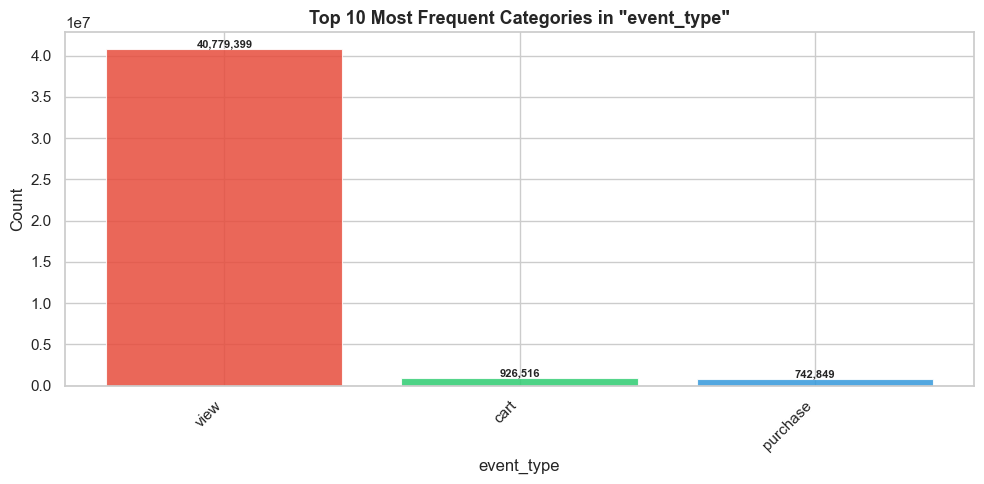

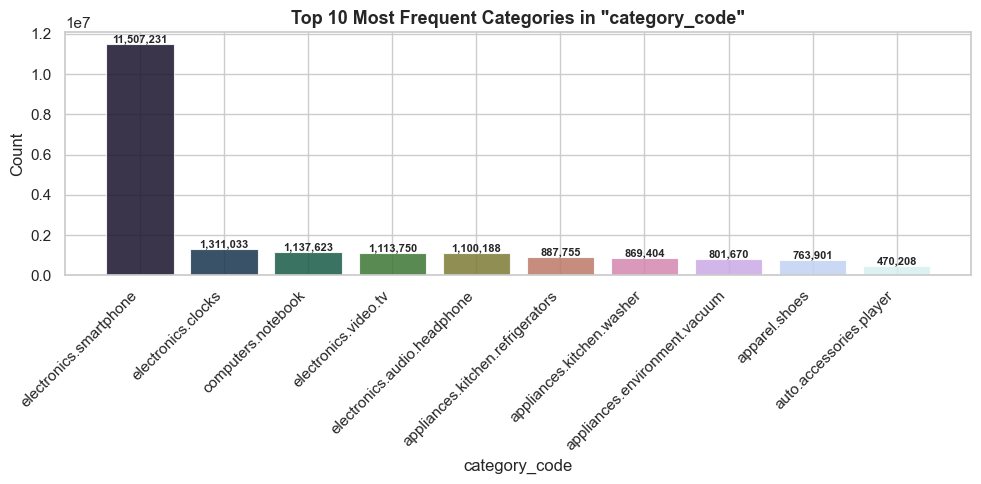

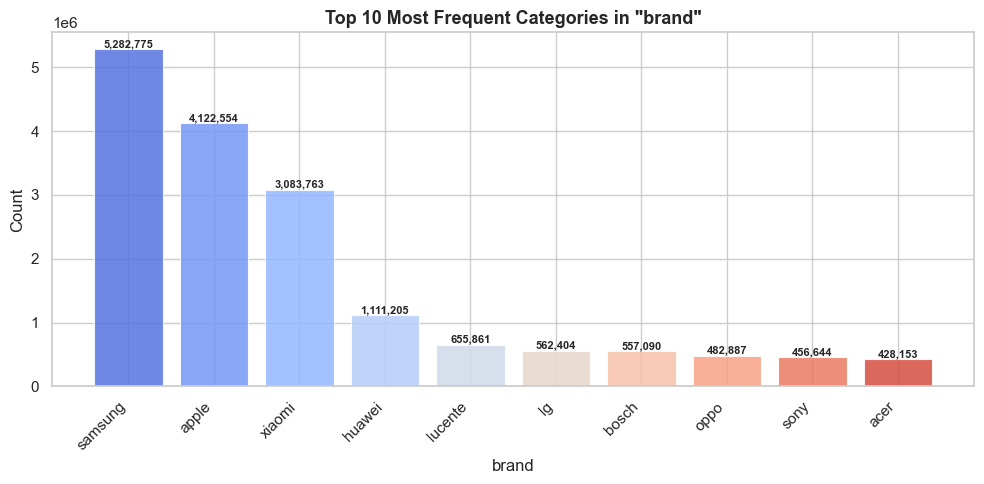

In [10]:
# Visualization of categorical columns
# Bar charts — shows top 10 most frequent values for each categorical column

sns.set(style="whitegrid")

categorical_cols = ['event_type', 'category_code', 'brand']

# Define a unique color palette for each column
column_colors = {
    'event_type'    : ['#E74C3C', '#2ECC71', '#3498DB'],                          # Red, Green, Blue — only 3 values
    'category_code' : sns.color_palette('cubehelix', 10).as_hex(),                # Cubehelix gradient for 10 categories
    'brand'         : sns.color_palette('coolwarm', 10).as_hex()                  # Coolwarm diverging for 10 brands
}

for col in categorical_cols:
    # Get top 10 most frequent values for the column
    top_categories = df[col].value_counts().nlargest(10)
    
    colors = column_colors[col][:len(top_categories)]  # Slice colors to match number of bars
    
    plt.figure(figsize=(10, 5))
    bars = plt.bar(top_categories.index, top_categories.values, 
                   color=colors, alpha=0.85, edgecolor='white', linewidth=0.8)
    
    # Add count labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:,}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    plt.title(f'Top 10 Most Frequent Categories in "{col}"', fontsize=13, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')  # Rotate labels to prevent overlap
    plt.tight_layout()
    plt.show()

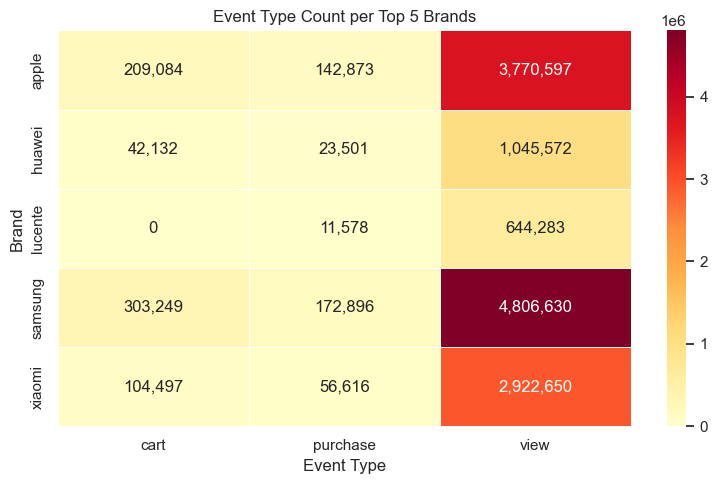

In [11]:
# Visualization of event type distribution across top 5 brands
# Heatmap — shows interaction intensity between brand and event type in a compact grid
# Best for identifying which brands drive the most purchases vs views

top_brands = df['brand'].value_counts().nlargest(5).index
df_top_brands = df[df['brand'].isin(top_brands)]

# Prepare pivot table: rows=brands, columns=event types, values=counts
brand_event = df_top_brands.groupby(['brand', 'event_type']).size().unstack(fill_value=0)

plt.figure(figsize=(8, 5))
sns.heatmap(brand_event, 
            annot=True,           # Show actual counts inside each cell
            fmt=',',              # Format numbers with commas
            cmap='YlOrRd',        # Yellow to Red colormap — higher values darker
            linewidths=0.5,       # Grid lines between cells
            linecolor='white')    # White grid lines for clean separation

plt.title('Event Type Count per Top 5 Brands')
plt.xlabel('Event Type')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

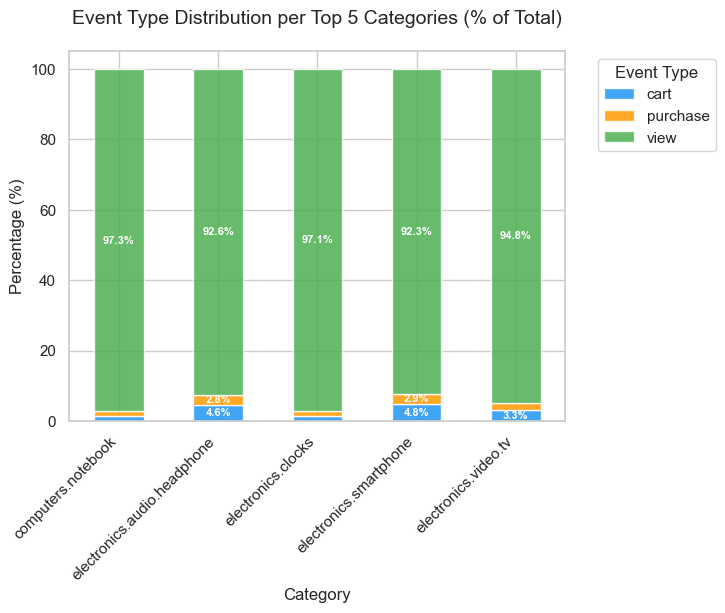

In [12]:
# Visualization of event type distribution across top 5 product categories
# 100% stacked bar — normalises counts to show conversion rate proportions per category
# Best for comparing funnel ratios across categories regardless of total volume differences

top_categories = df['category_code'].value_counts().nlargest(5).index
df_top_categories = df[df['category_code'].isin(top_categories)]

# Prepare and normalise data to percentages
category_event = df_top_categories.groupby(['category_code', 'event_type']).size().unstack(fill_value=0)
category_event_pct = category_event.div(category_event.sum(axis=1), axis=0) * 100  # Convert to percentage

colors = ['#2196F3', '#FF9800', '#4CAF50']  # Blue=view, Orange=cart, Green=purchase

# Create figure with constrained layout to prevent black space
plt.figure(figsize=(14, 8), constrained_layout=True)

category_event_pct.plot(kind='bar', stacked=True, 
                        color=colors, alpha=0.85, edgecolor='white')

# Add percentage labels inside each stack
for n, col in enumerate(category_event_pct.columns):
    for i, (idx, val) in enumerate(category_event_pct[col].items()):
        if val > 2:  # Only label if slice is large enough to display
            # Calculate cumulative position for label placement
            cumsum = category_event_pct.iloc[i, :n+1].sum()
            plt.text(i, cumsum - val/2,  
                     f'{val:.1f}%', ha='center', va='center', 
                     fontsize=8, fontweight='bold', color='white')

plt.title('Event Type Distribution per Top 5 Categories (% of Total)', fontsize=14, pad=20)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Event Type', bbox_to_anchor=(1.05, 1))

# Remove tight_layout() since we're using constrained_layout
plt.show()

### Data Cleaning

In [13]:
# Identifying and handling missing values
# Drops rows with missing values in category_code and brand columns

print("Missing values BEFORE cleaning:")
print("="*40)
print(df.isnull().sum())  # Display missing value counts for all columns before cleaning
print(f"\nDataset shape before cleaning: {df.shape}")

# Remove rows where category_code is null — insufficient data for category-level modelling
df = df[df['category_code'].notnull()]

# Remove rows where brand is null — required for brand-level analysis
df = df[df['brand'].notnull()]

print("\nMissing values AFTER cleaning:")
print("="*40)
print(df.isnull().sum())  # Confirm nulls removed successfully
print(f"\nDataset shape after cleaning: {df.shape}")
print("\nMissing values handled (by removing rows)")

Missing values BEFORE cleaning:
event_time              0
event_type              0
product_id              0
category_id             0
category_code    13515609
brand             6117080
price                   0
user_id                 0
user_session            2
dtype: int64

Dataset shape before cleaning: (42448764, 9)

Missing values AFTER cleaning:
event_time       0
event_type       0
product_id       0
category_id      0
category_code    0
brand            0
price            0
user_id          0
user_session     2
dtype: int64

Dataset shape after cleaning: (26560622, 9)

Missing values handled (by removing rows)


In [14]:
# Additional data cleaning — price validation and event type confirmation

print("Dataset shape before:", df.shape)
print("="*50)

# Remove rows where price is zero or negative — invalid transactions
before = df.shape[0]
df = df[df['price'] > 0]
print(f"Rows removed due to invalid price (<=0): {df.shape[0] - before:,}")

# Confirm only valid event types exist — view, cart, purchase
before = df.shape[0]
df = df[df['event_type'].isin(['view', 'cart', 'purchase'])]
print(f"Rows removed due to invalid event_type: {before - df.shape[0]:,}")

print("="*50)
print("Dataset shape after:", df.shape)

Dataset shape before: (26560622, 9)
Rows removed due to invalid price (<=0): 0
Rows removed due to invalid event_type: 0
Dataset shape after: (26560622, 9)


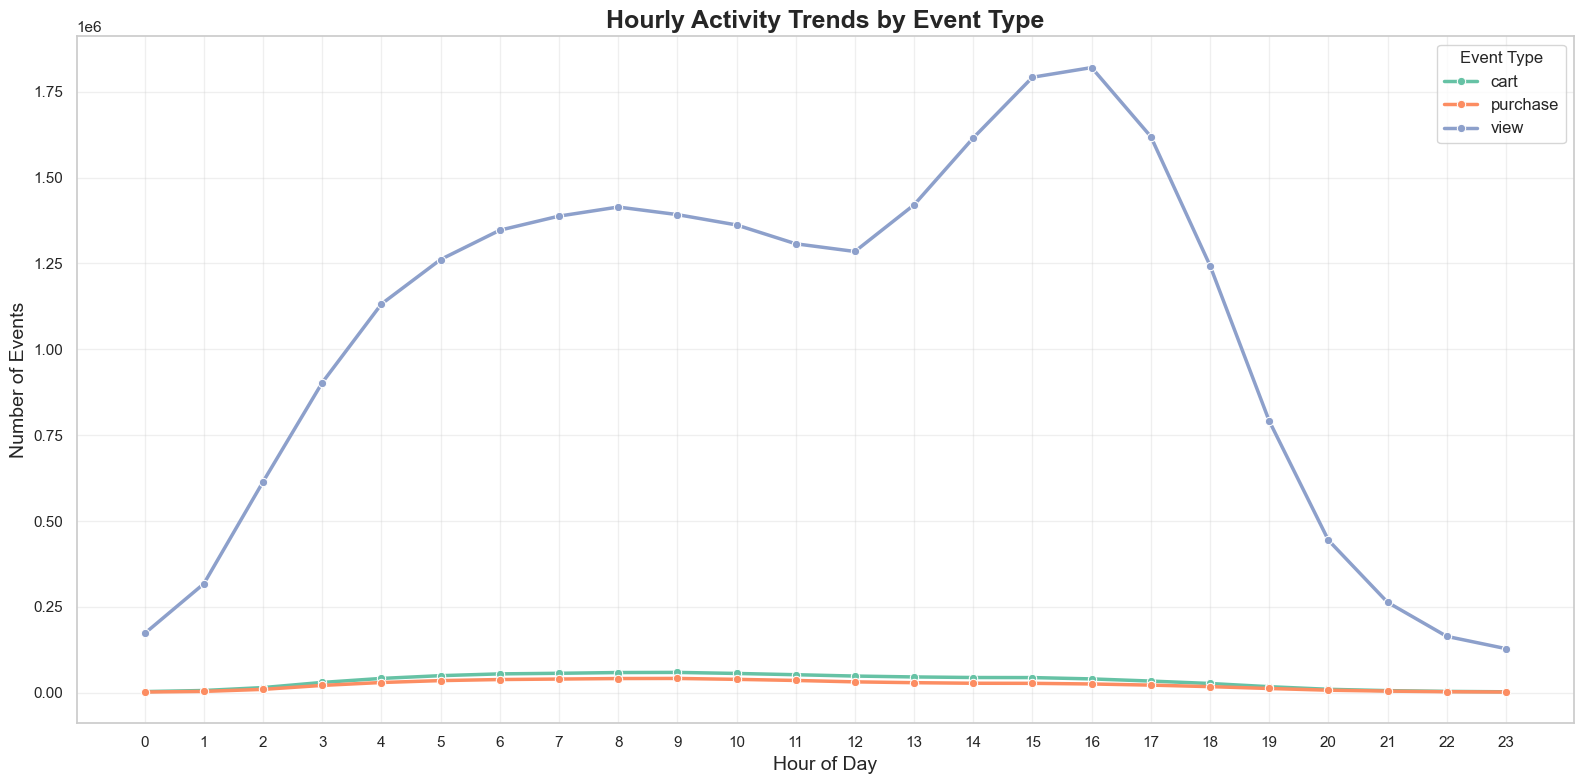

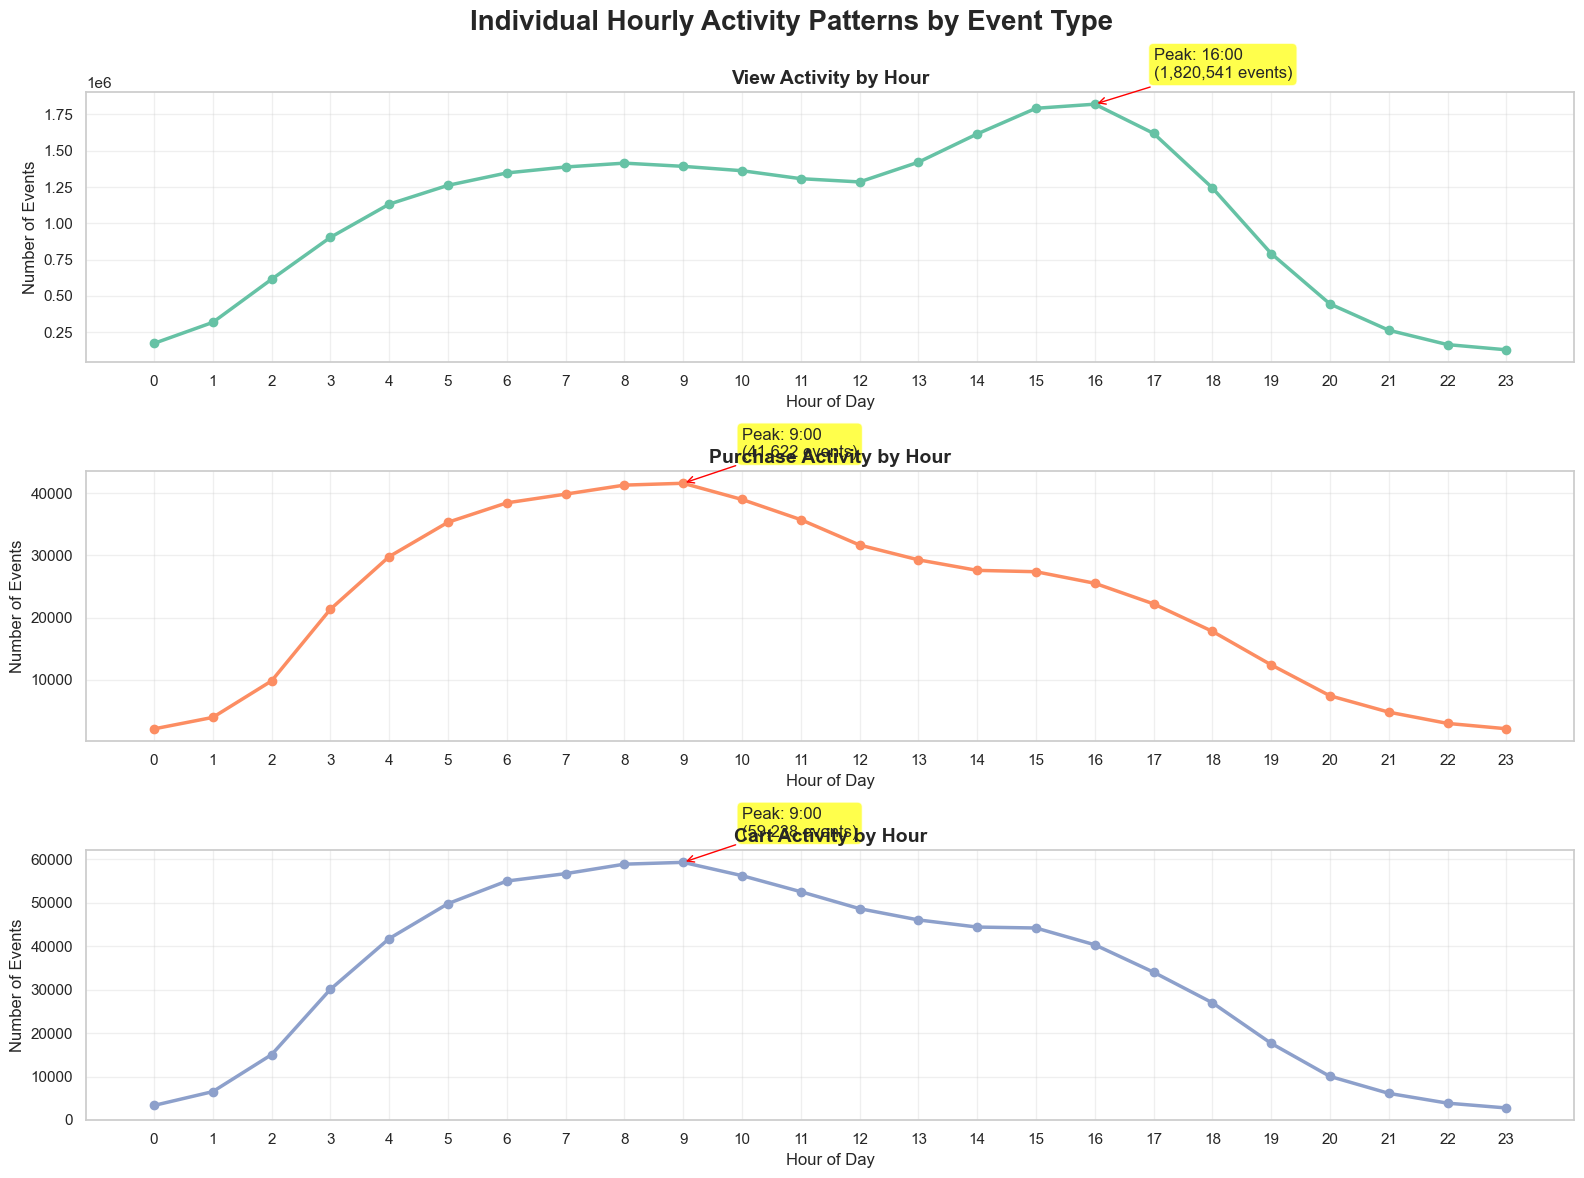

In [20]:
# Hourly Activity Pattern (User Behavior by Hour)
# Combined + Individual line plots — shows overall trend and per-event-type breakdown

# First, convert event_time to datetime
df['event_time'] = pd.to_datetime(df['event_time'], errors='coerce')

# Extract hour from event_time for hourly analysis
df['event_hour'] = df['event_time'].dt.hour

# Aggregate event counts by hour and event type
hourly_counts = df.groupby(['event_hour', 'event_type']).size().reset_index(name='count')

# Combined line chart
plt.figure(figsize=(16, 8))
sns.lineplot(data=hourly_counts, x='event_hour', y='count', 
             hue='event_type', marker='o', linewidth=2.5, palette='Set2')
plt.title('Hourly Activity Trends by Event Type', fontsize=18, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=14)
plt.ylabel('Number of Events', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.legend(title='Event Type', fontsize=12)
plt.tight_layout()
plt.show()

# Individual line charts for each event type
event_types = df['event_type'].unique()
colors = ['#66c2a5', '#fc8d62', '#8da0cb']

fig, axes = plt.subplots(len(event_types), 1, figsize=(16, 4*len(event_types)))
fig.suptitle('Individual Hourly Activity Patterns by Event Type', fontsize=20, fontweight='bold', y=0.98)

for i, event_type in enumerate(event_types):
    # Filter data for specific event type
    event_data = hourly_counts[hourly_counts['event_type'] == event_type]
    
    # Create line plot
    axes[i].plot(event_data['event_hour'], event_data['count'], 
                 marker='o', linewidth=2.5, color=colors[i], markersize=6)
    
    # Formatting
    axes[i].set_title(f'{event_type.title()} Activity by Hour', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Hour of Day', fontsize=12)
    axes[i].set_ylabel('Number of Events', fontsize=12)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xticks(range(0, 24))
    
    # Add peak hour annotation
    peak_hour = event_data.loc[event_data['count'].idxmax()]
    axes[i].annotate(f'Peak: {int(peak_hour["event_hour"])}:00\n({int(peak_hour["count"]):,} events)',
                    xy=(peak_hour['event_hour'], peak_hour['count']),
                    xytext=(peak_hour['event_hour']+1, peak_hour['count']*1.1),
                    arrowprops=dict(arrowstyle='->', color='red'),
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

Total unique buyers:       263,445
One-time buyers:           168,003 (63.8%)
Repeat buyers:             95,442 (36.2%)

Top 5 repeat buyers:
user_id
512386086    322
523974502    288
513320236    242
543312954    193
519267944    183
Name: count, dtype: int64


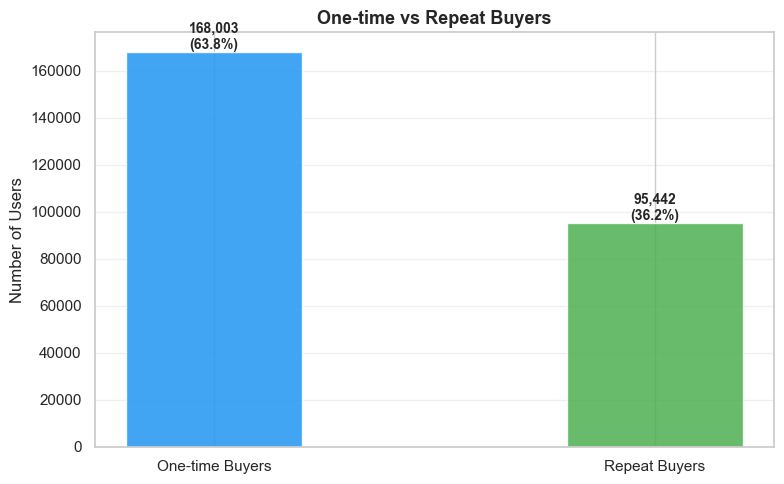

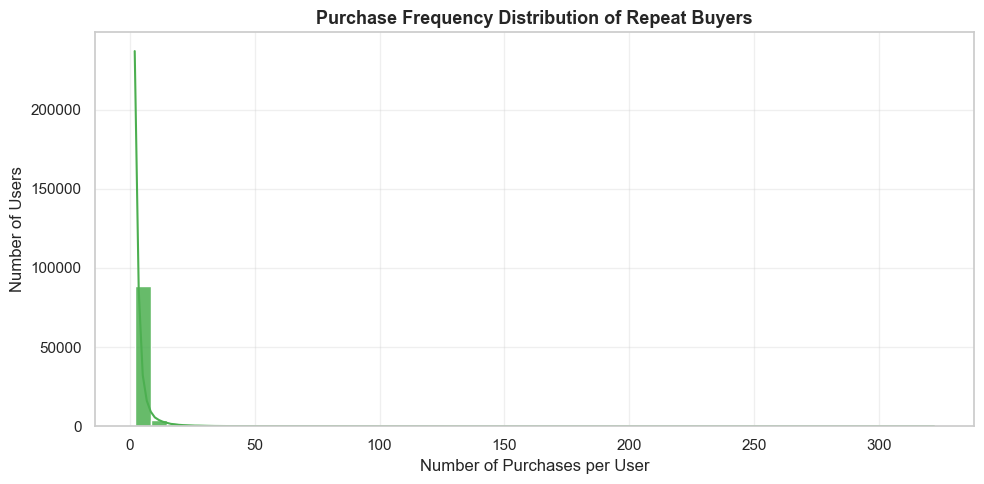

In [18]:
# Repeat Purchase Analysis
# Identifies users who made more than one purchase — key indicator for CLV modelling

# Filter purchase events only
purchase_df = df[df['event_type'] == 'purchase']

# Count purchases per user
user_purchase_counts = purchase_df['user_id'].value_counts()

# Separate repeat buyers (more than 1 purchase) from one-time buyers
repeat_buyers = user_purchase_counts[user_purchase_counts > 1]
one_time_buyers = user_purchase_counts[user_purchase_counts == 1]

print("="*50)
print(f"Total unique buyers:       {len(user_purchase_counts):,}")
print(f"One-time buyers:           {len(one_time_buyers):,} ({len(one_time_buyers)/len(user_purchase_counts)*100:.1f}%)")
print(f"Repeat buyers:             {len(repeat_buyers):,} ({len(repeat_buyers)/len(user_purchase_counts)*100:.1f}%)")
print("="*50)
print(f"\nTop 5 repeat buyers:")
print(repeat_buyers.head())
print("="*50)

# ── Visualization 1: One-time vs Repeat Buyers ───────────────────────
labels = ['One-time Buyers', 'Repeat Buyers']
values = [len(one_time_buyers), len(repeat_buyers)]
colors = ['#2196F3', '#4CAF50']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors, alpha=0.85, edgecolor='white', width=0.4)

# Add count and percentage labels on top of each bar
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{val:,}\n({val/len(user_purchase_counts)*100:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('One-time vs Repeat Buyers', fontsize=13, fontweight='bold')
plt.ylabel('Number of Users')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ── Visualization 2: Purchase Frequency Distribution of Repeat Buyers ─
plt.figure(figsize=(10, 5))
sns.histplot(repeat_buyers.values, bins=50, color='#4CAF50', alpha=0.85, kde=True)

plt.title('Purchase Frequency Distribution of Repeat Buyers', fontsize=13, fontweight='bold')
plt.xlabel('Number of Purchases per User')
plt.ylabel('Number of Users')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

  Average Order Value (AOV):   $335.15
  Median Order Value:          $215.68
  Minimum Order Value:         $0.88
  Maximum Order Value:         $2574.04
  Total unique buyers:         263,445


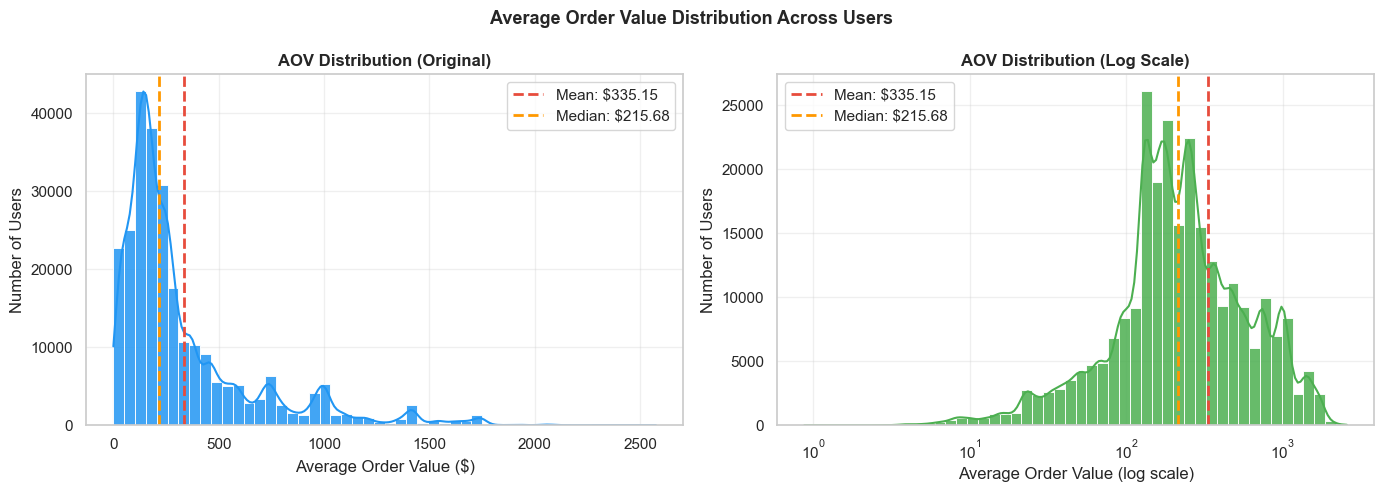

In [19]:
# Average Order Value (AOV) Analysis
# AOV = mean price per purchase transaction across all users

# ── Core Calculation ─────────────────────────────────────────────────

# Average order value per user first, then overall mean
user_aov = purchase_df.groupby('user_id')['price'].mean()  # AOV per individual user
overall_aov = user_aov.mean()                               # Overall AOV across all users
median_aov = user_aov.median()                              # Median AOV — less sensitive to outliers
min_aov = user_aov.min()                                    # Minimum AOV
max_aov = user_aov.max()                                    # Maximum AOV

print("="*50)
print(f"  Average Order Value (AOV):   ${overall_aov:.2f}")
print(f"  Median Order Value:          ${median_aov:.2f}")
print(f"  Minimum Order Value:         ${min_aov:.2f}")
print(f"  Maximum Order Value:         ${max_aov:.2f}")
print(f"  Total unique buyers:         {len(user_aov):,}")
print("="*50)

# ── Visualization: AOV Distribution Across Users ─────────────────────
# Distribution of per-user AOV — reveals spending spread and skew

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # Side by side: raw and log scale

# Left: Raw AOV distribution
sns.histplot(user_aov, bins=50, color='#2196F3', alpha=0.85, kde=True, ax=axes[0])
axes[0].axvline(overall_aov, color='#E74C3C', linewidth=2, 
                linestyle='--', label=f'Mean: ${overall_aov:.2f}')   # Mean reference line
axes[0].axvline(median_aov, color='#FF9800', linewidth=2, 
                linestyle='--', label=f'Median: ${median_aov:.2f}')  # Median reference line
axes[0].set_title('AOV Distribution (Original)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Order Value ($)')
axes[0].set_ylabel('Number of Users')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Log scale AOV distribution — handles right skew for clearer shape
sns.histplot(user_aov, bins=50, color='#4CAF50', alpha=0.85, 
             kde=True, log_scale=True, ax=axes[1])
axes[1].axvline(overall_aov, color='#E74C3C', linewidth=2, 
                linestyle='--', label=f'Mean: ${overall_aov:.2f}')
axes[1].axvline(median_aov, color='#FF9800', linewidth=2, 
                linestyle='--', label=f'Median: ${median_aov:.2f}')
axes[1].set_title('AOV Distribution (Log Scale)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Order Value (log scale)')
axes[1].set_ylabel('Number of Users')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Average Order Value Distribution Across Users', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Transactional Feature Engineering
# Builds user-level feature matrix from raw event data for CLV modelling
# Features grouped into 4 categories: transactional, behavioural, time-based, category

def engineer_transactional_features(df):

    # ── 1. Transactional Features ────────────────────────────────────
    purchase_data = df[df['event_type'] == 'purchase']  # Filter purchase events only

    # Total spend per user — primary CLV target proxy
    total_purchase_amount = purchase_data.groupby('user_id')['price'].sum().reset_index()
    total_purchase_amount.rename(columns={'price': 'total_purchase_amount'}, inplace=True)

    # Number of purchases per user
    num_purchases = purchase_data.groupby('user_id')['product_id'].count().reset_index()
    num_purchases.rename(columns={'product_id': 'num_purchases'}, inplace=True)

    # Average order value = total spend / number of purchases
    avg_order_value = total_purchase_amount.merge(num_purchases, on='user_id')
    avg_order_value['avg_order_value'] = (avg_order_value['total_purchase_amount'] /
                                          avg_order_value['num_purchases'])

    # ── 2. Behavioural Interaction Features ──────────────────────────
    # Total views per user — measures browsing intensity
    total_views = df[df['event_type'] == 'view'].groupby('user_id')['product_id'].count().reset_index()
    total_views.rename(columns={'product_id': 'total_views'}, inplace=True)

    # Total cart additions per user — measures purchase intent
    total_carts = df[df['event_type'] == 'cart'].groupby('user_id')['product_id'].count().reset_index()
    total_carts.rename(columns={'product_id': 'total_carts'}, inplace=True)

    # Merge view and cart counts — outer join retains all users
    behavior_features = total_views.merge(total_carts, on='user_id', how='outer').fillna(0)
    behavior_features = behavior_features.merge(num_purchases, on='user_id', how='left')

    # Cart abandonment rate = (carts - purchases) / carts
    # Clipped at 0 to avoid negative values from data inconsistencies
    behavior_features['cart_abandonment_rate'] = (
        (behavior_features['total_carts'] - behavior_features['num_purchases'])
        .clip(lower=0) / behavior_features['total_carts'].replace(0, np.nan)
    )

    # Conversion rate = purchases / views
    # replace(0, nan) avoids division by zero for users with no views
    behavior_features['conversion_rate'] = (
        behavior_features['num_purchases'] /
        behavior_features['total_views'].replace(0, np.nan)
    )

    # ── 3. Time-Based Features ───────────────────────────────────────
    # Recency = days since last purchase relative to dataset end date
    last_purchase = purchase_data.groupby('user_id')['event_time'].max().reset_index()
    last_purchase['recency_days'] = (df['event_time'].max() - last_purchase['event_time']).dt.days

    # First purchase gap = days between first view and first purchase
    # Measures how long users take to convert from browsing to buying
    first_view = df[df['event_type'] == 'view'].groupby('user_id')['event_time'].min().reset_index()
    first_purchase = purchase_data.groupby('user_id')['event_time'].min().reset_index()

    purchase_gap = first_view.merge(first_purchase, on='user_id', suffixes=('_view', '_purchase'))
    purchase_gap['first_purchase_gap_days'] = (
        purchase_gap['event_time_purchase'] - purchase_gap['event_time_view']
    ).dt.days

    # ── 4. Category Features ─────────────────────────────────────────
    # Top category = most purchased category per user
    top_category = (purchase_data.groupby(['user_id', 'category_code'])['product_id']
                    .count().reset_index()
                    .sort_values(['user_id', 'product_id'], ascending=[True, False])
                    .drop_duplicates('user_id'))
    top_category.rename(columns={'category_code': 'top_category'}, inplace=True)

    # Category diversity = number of unique categories a user interacted with
    category_diversity = df.groupby('user_id')['category_code'].nunique().reset_index()
    category_diversity.rename(columns={'category_code': 'category_diversity'}, inplace=True)

    # ── 5. Final Merge ───────────────────────────────────────────────
    # Sequentially merge all feature groups on user_id
    final_features = total_purchase_amount.merge(
        avg_order_value[['user_id', 'avg_order_value']], on='user_id', how='left')
    final_features = final_features.merge(
        num_purchases, on='user_id', how='left')
    final_features = final_features.merge(
        behavior_features[['user_id', 'total_views', 'total_carts',
                           'cart_abandonment_rate', 'conversion_rate']], on='user_id', how='left')
    final_features = final_features.merge(
        last_purchase[['user_id', 'recency_days']], on='user_id', how='left')
    final_features = final_features.merge(
        purchase_gap[['user_id', 'first_purchase_gap_days']], on='user_id', how='left')
    final_features = final_features.merge(
        top_category[['user_id', 'top_category']], on='user_id', how='left')
    final_features = final_features.merge(
        category_diversity, on='user_id', how='left')

    # Fill remaining NaN with 0 — users missing certain event types default to 0
    return final_features.fillna(0)

# Run transactional feature engineering and store result
trans_df = engineer_transactional_features(df)
print(f"Transactional feature matrix shape : {trans_df.shape}")
print(f"Features: {list(trans_df.columns)}")
print("\nSample output:")
print(trans_df.head())

Transactional feature matrix shape : (263445, 12)
Features: ['user_id', 'total_purchase_amount', 'avg_order_value', 'num_purchases', 'total_views', 'total_carts', 'cart_abandonment_rate', 'conversion_rate', 'recency_days', 'first_purchase_gap_days', 'top_category', 'category_diversity']

Sample output:
     user_id  total_purchase_amount  avg_order_value  num_purchases  \
0  303160429                 340.59           340.59              1   
1  340041246                 339.70           339.70              1   
2  384989212                  41.44            41.44              1   
3  401021311                 231.64           231.64              1   
4  403013066                 807.16           403.58              2   

   total_views  total_carts  cart_abandonment_rate  conversion_rate  \
0          2.0          0.0               0.000000         0.500000   
1         28.0          0.0               0.000000         0.035714   
2        128.0          0.0               0.000000      

In [22]:
# Behavioural Feature Engineering
# Builds user-level behavioural features from session and event interaction data
# Features grouped into: session-level, event counts, and funnel ratios
# Note: total_purchase_amount is handled in transactional features — not duplicated here

def engineer_behavioural_features(df):

    # ── 1. Session-Level Features ────────────────────────────────────
    user_summary = df.groupby('user_id').agg(
        sessions_per_user  = ('user_session', 'nunique'),          # Number of unique sessions per user
        active_duration    = ('event_time', lambda x:
                              (x.max() - x.min()).total_seconds()), # Total active time in seconds
        category_diversity = ('category_code', pd.Series.nunique)  # Number of unique categories browsed
    ).reset_index()

    # ── 2. Event Type Counts ─────────────────────────────────────────
    # Pivot to get view, cart, purchase counts as separate columns per user
    event_counts = df.pivot_table(
        index='user_id',
        columns='event_type',
        aggfunc='size',
        fill_value=0
    ).reset_index()
    event_counts.columns.name = None  # Remove MultiIndex column name for clean merging

    # Ensure all three event type columns exist — handles edge cases where
    # a user may have no cart or purchase events
    for col in ['view', 'cart', 'purchase']:
        if col not in event_counts.columns:
            event_counts[col] = 0

    # Rename for clarity
    event_counts = event_counts.rename(columns={
        'view'    : 'view_count',
        'cart'    : 'cart_count',
        'purchase': 'purchase_count'
    })

    # ── 3. Funnel Ratio Features ─────────────────────────────────────
    # Cart-to-view ratio — measures browsing to cart conversion tendency
    # replace(0,1) avoids division by zero for users with no views
    event_counts['cart_to_view_ratio'] = (
        event_counts['cart_count'] / event_counts['view_count'].replace(0, 1)
    )

    # Purchase rate — measures overall conversion from browsing to purchase
    event_counts['purchase_rate'] = (
        event_counts['purchase_count'] / event_counts['view_count'].replace(0, 1)
    )

    # ── 4. Merge Session and Event Features ──────────────────────────
    behavioural_df = user_summary.merge(event_counts, on='user_id', how='left')

    # ── 5. Data Quality Filters ──────────────────────────────────────
    # Replace inf values from ratio calculations with 0
    behavioural_df = behavioural_df.replace([np.inf, -np.inf], 0).fillna(0)

    # Remove users with no views — insufficient behavioural data for modelling
    behavioural_df = behavioural_df[behavioural_df['view_count'] > 0]

    return behavioural_df

# Run behavioural feature engineering and store result
beh_df = engineer_behavioural_features(df)
print(f"Behavioural feature matrix shape: {beh_df.shape}")
print(f"Features: {list(beh_df.columns)}")
print("\nSample output:")
print(beh_df.head())

Behavioural feature matrix shape: (2322867, 9)
Features: ['user_id', 'sessions_per_user', 'active_duration', 'category_diversity', 'cart_count', 'purchase_count', 'view_count', 'cart_to_view_ratio', 'purchase_rate']

Sample output:
     user_id  sessions_per_user  active_duration  category_diversity  \
0   33869381                  1              0.0                   1   
1  184265397                  1            387.0                   1   
2  195082191                  1              0.0                   1   
3  200673532                  3         257025.0                   2   
4  208669541                  1              0.0                   1   

   cart_count  purchase_count  view_count  cart_to_view_ratio  purchase_rate  
0           0               0           1                 0.0            0.0  
1           0               0           4                 0.0            0.0  
2           0               0           1                 0.0            0.0  
3           0      

In [23]:
# Merging Transactional and Behavioural Feature Sets

# Identify and remove overlapping columns from beh_df before merging
overlapping_columns = set(trans_df.columns) & set(beh_df.columns) - {'user_id'}
print(f"Overlapping columns removed from beh_df: {overlapping_columns}")

# Drop overlapping columns from beh_df — transactional version takes priority
beh_df_cleaned = beh_df.drop(columns=overlapping_columns)

# Merge cleaned DataFrames
hybrid_df = pd.merge(trans_df, beh_df_cleaned, on='user_id', how='inner')

print(f"\nTransactional features shape : {trans_df.shape}")
print(f"Behavioural features shape   : {beh_df.shape}")
print(f"Merged hybrid matrix shape   : {hybrid_df.shape}")
print(f"\nAll features: {list(hybrid_df.columns)}")
print(hybrid_df.head())

Overlapping columns removed from beh_df: {'category_diversity'}

Transactional features shape : (263445, 12)
Behavioural features shape   : (2322867, 9)
Merged hybrid matrix shape   : (263380, 19)

All features: ['user_id', 'total_purchase_amount', 'avg_order_value', 'num_purchases', 'total_views', 'total_carts', 'cart_abandonment_rate', 'conversion_rate', 'recency_days', 'first_purchase_gap_days', 'top_category', 'category_diversity', 'sessions_per_user', 'active_duration', 'cart_count', 'purchase_count', 'view_count', 'cart_to_view_ratio', 'purchase_rate']
     user_id  total_purchase_amount  avg_order_value  num_purchases  \
0  303160429                 340.59           340.59              1   
1  340041246                 339.70           339.70              1   
2  384989212                  41.44            41.44              1   
3  401021311                 231.64           231.64              1   
4  403013066                 807.16           403.58              2   

   total

### Visualisation after Feature Engineering

Features available for plotting: ['avg_order_value', 'num_purchases', 'category_diversity', 'total_views', 'cart_abandonment_rate', 'conversion_rate', 'total_carts', 'recency_days', 'first_purchase_gap_days']


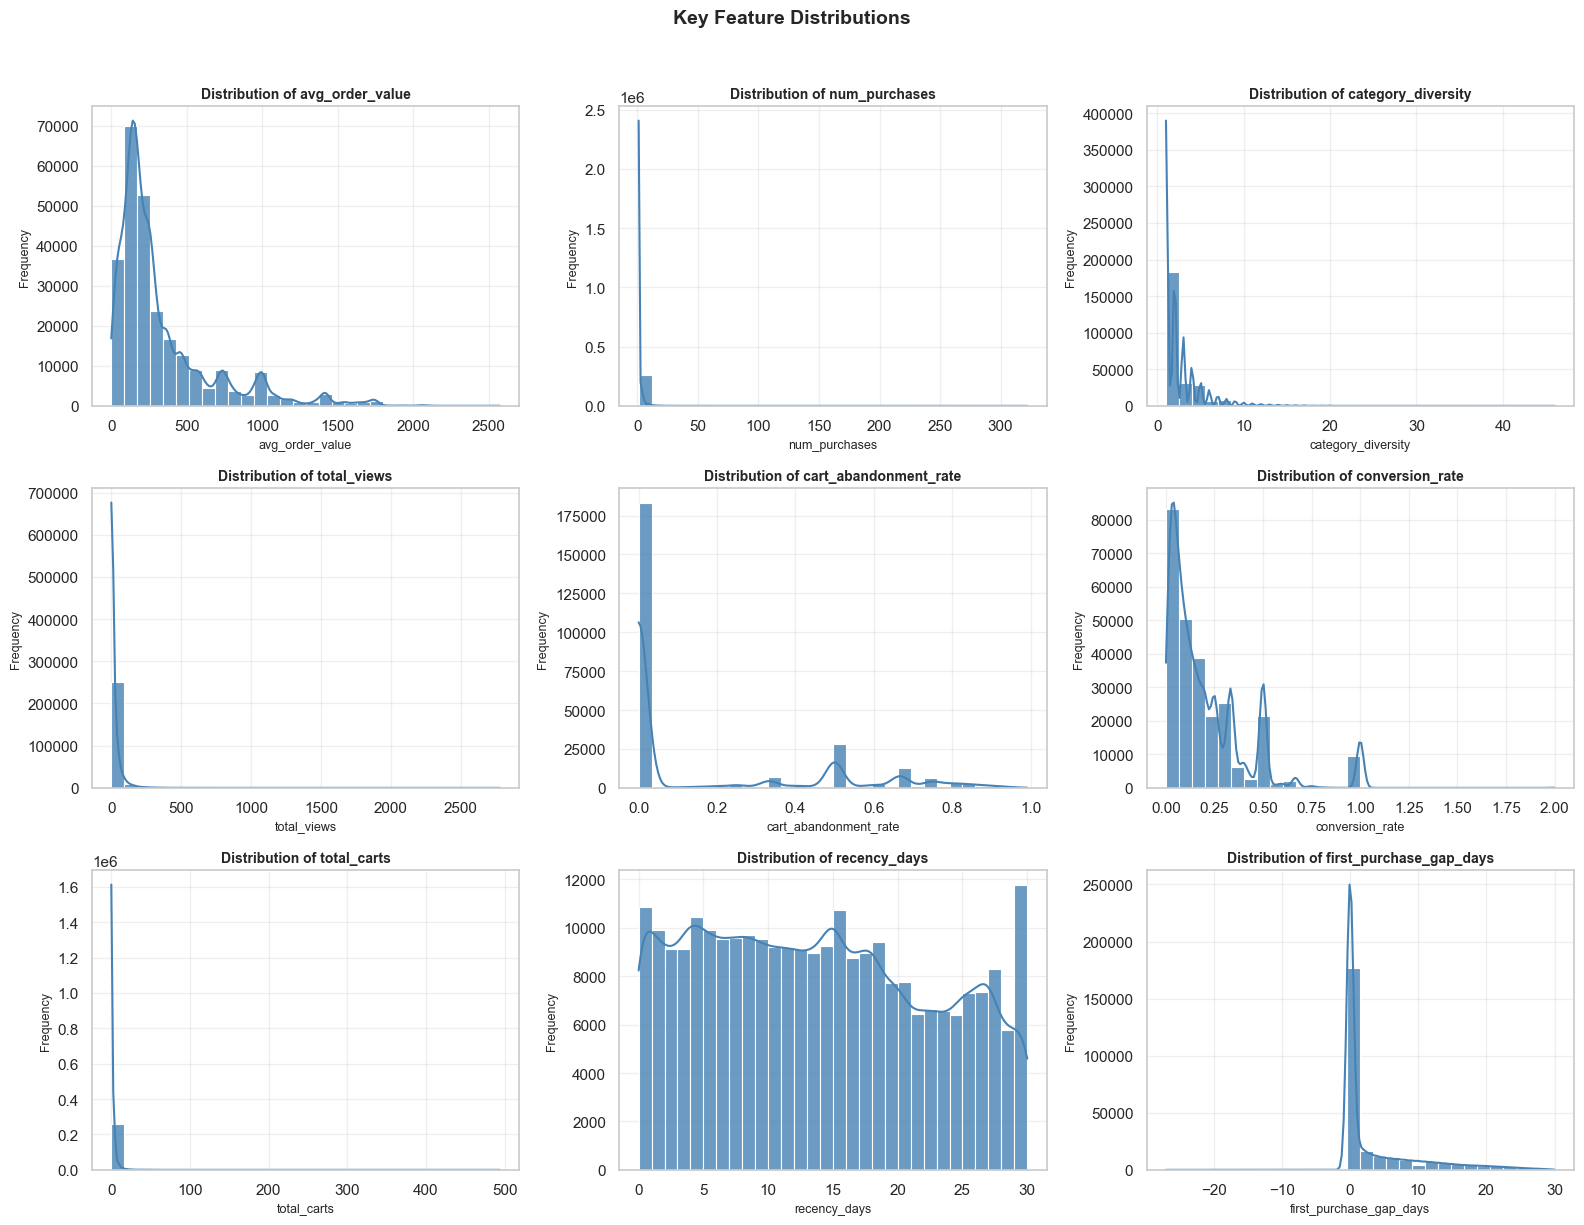

C:\Users\shire\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\shire\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\shire\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\shire\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encou

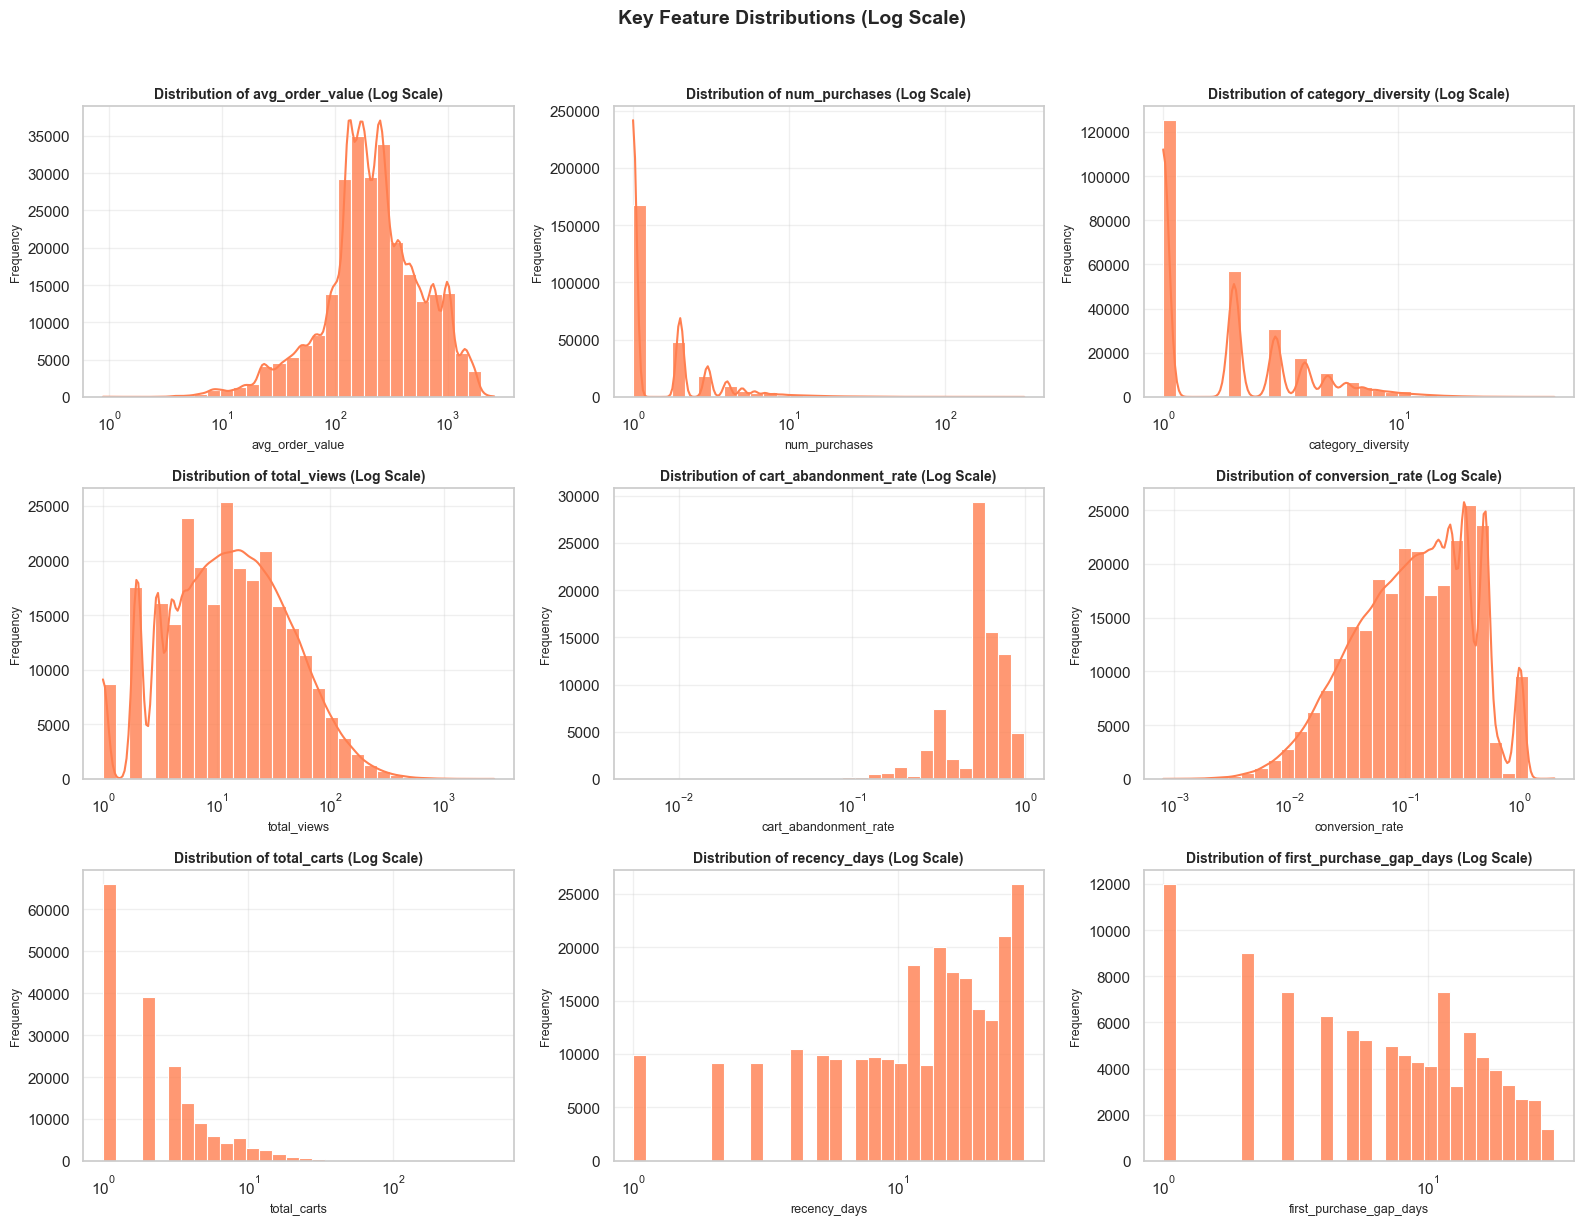

In [24]:
# Visualising key feature distributions
# Grid layout — all 9 numeric features in one figure for compact academic presentation

sns.set(style="whitegrid")

# Verify all features exist in hybrid_df before plotting
numeric_features = [f for f in [
    'avg_order_value', 'num_purchases', 'category_diversity', 'total_views',
    'cart_abandonment_rate', 'conversion_rate', 'total_carts',
    'recency_days', 'first_purchase_gap_days'
] if f in hybrid_df.columns]  # Only keep features that actually exist

print(f"Features available for plotting: {numeric_features}")

# ── Option 1: 3x3 Grid (Recommended) ────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))  # 3 rows x 3 columns grid
axes = axes.flatten()                              # Flatten to iterate easily

for i, feature in enumerate(numeric_features):
    sns.histplot(hybrid_df[feature], kde=True, bins=30, 
                 color='steelblue', alpha=0.8, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Key Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Option 2: Log Scale Grid (Better for skewed features) ────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(hybrid_df[feature], kde=True, bins=30,
                 color='coral', alpha=0.8, ax=axes[i], log_scale=True)  # Log scale handles right skew
    axes[i].set_title(f'Distribution of {feature} (Log Scale)', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Key Feature Distributions (Log Scale)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Features included in correlation matrix: ['avg_order_value', 'num_purchases', 'category_diversity', 'total_views', 'cart_abandonment_rate', 'conversion_rate', 'total_carts', 'recency_days', 'first_purchase_gap_days', 'total_purchase_amount']


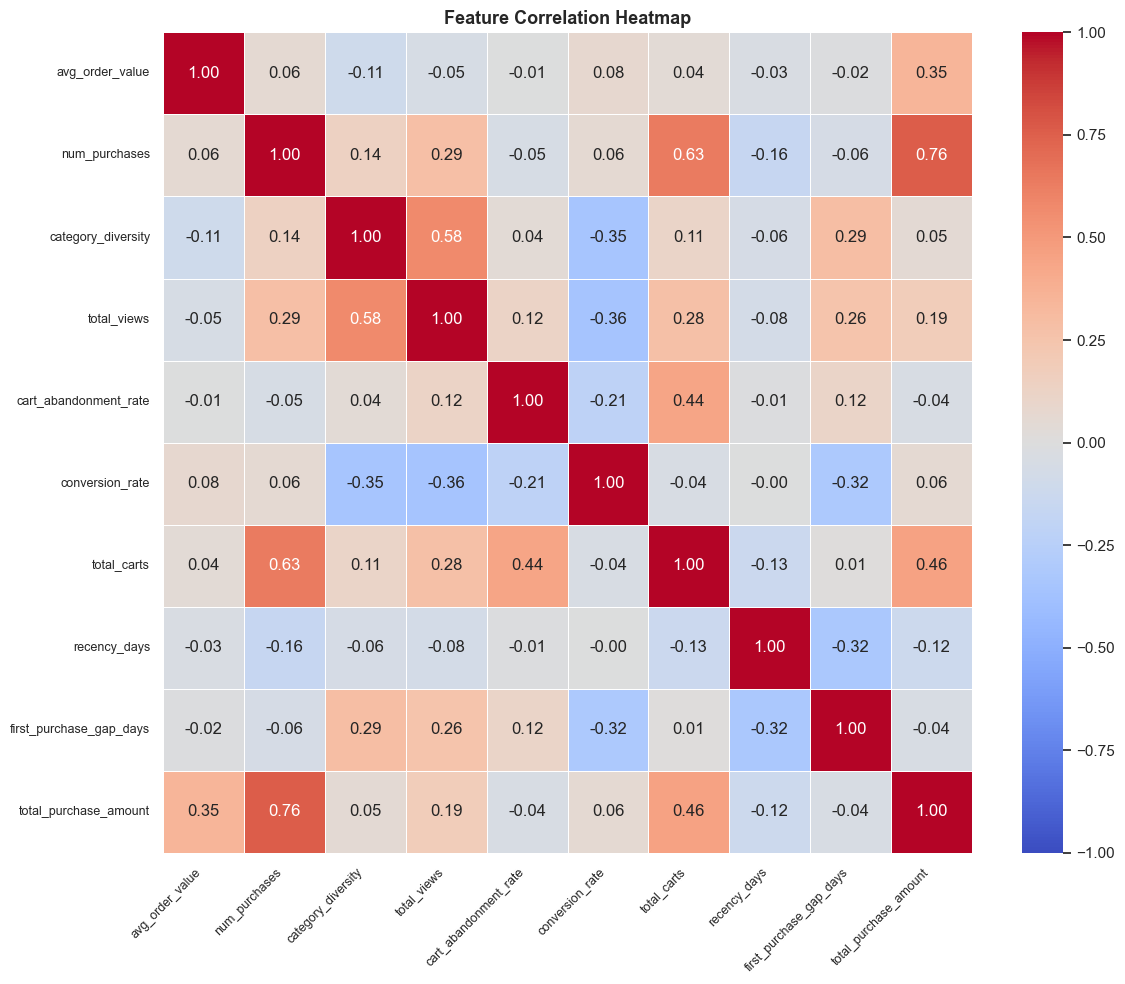

In [25]:
# Correlation Heatmap
# Shows pairwise correlation between all numeric features and CLV target variable
# Helps identify multicollinearity and strongest predictors of total_purchase_amount

import warnings

# Build feature list — only include columns that actually exist in hybrid_df
corr_features = [f for f in numeric_features + ['total_purchase_amount'] 
                 if f in hybrid_df.columns]

print(f"Features included in correlation matrix: {corr_features}")

# Suppress RuntimeWarning from NaN values during correlation calculation
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    corr = hybrid_df[corr_features].corr()  # Compute pairwise Pearson correlation

plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            annot=True,           # Show correlation values inside each cell
            cmap='coolwarm',      # Red = positive, Blue = negative correlation
            fmt='.2f',            # Round to 2 decimal places
            linewidths=0.5,       # Grid lines between cells
            linecolor='white',    # White grid lines for clean separation
            vmin=-1, vmax=1)      # Fix scale to full correlation range

plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)   # Rotate x labels to prevent overlap
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

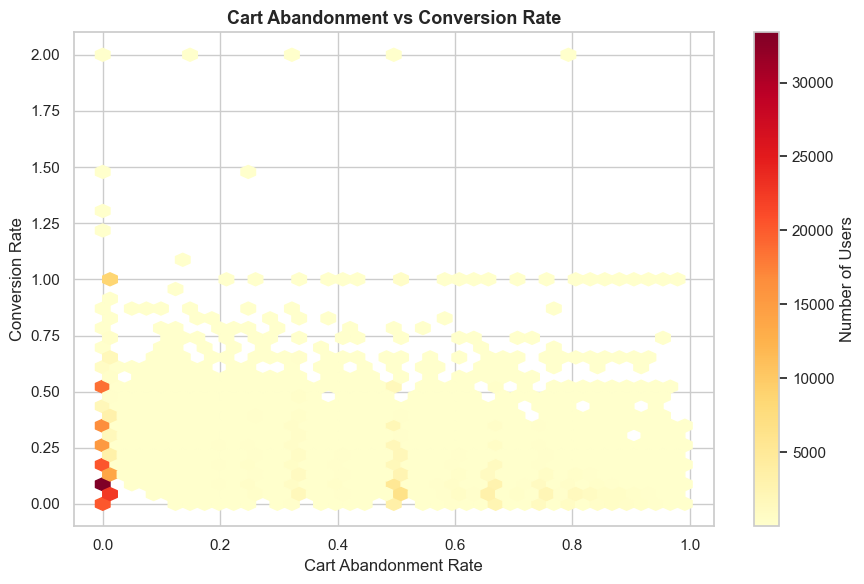

In [26]:
# Cart Abandonment vs Conversion Rate
# Hexbin plot — handles overplotting on large datasets by grouping points into hex bins
# Darker hexagons = higher density of users in that region

plt.figure(figsize=(9, 6))
plt.hexbin(hybrid_df['cart_abandonment_rate'],
           hybrid_df['conversion_rate'],
           gridsize=40,              # Number of hexagons across x-axis
           cmap='YlOrRd',            # Yellow to Red — darker = more users
           mincnt=1)                 # Only show hexagons with at least 1 user

plt.colorbar(label='Number of Users')  # Color scale legend
plt.title('Cart Abandonment vs Conversion Rate', fontsize=13, fontweight='bold')
plt.xlabel('Cart Abandonment Rate')
plt.ylabel('Conversion Rate')
plt.tight_layout()
plt.show()

## Hybrid Machine Learning modelling for CLV Prediction 

# Behavioral CLV Prediction with Random Forest
## Overview
This section implements a Random Forest regression model to predict Customer Lifetime Value (CLV) using behavioral features. The approach leverages user interaction patterns, engagement metrics and conversion behaviors to estimate future customer value.

In [27]:
print(beh_df.columns.tolist())
print(trans_df.columns.tolist())

['user_id', 'sessions_per_user', 'active_duration', 'category_diversity', 'cart_count', 'purchase_count', 'view_count', 'cart_to_view_ratio', 'purchase_rate']
['user_id', 'total_purchase_amount', 'avg_order_value', 'num_purchases', 'total_views', 'total_carts', 'cart_abandonment_rate', 'conversion_rate', 'recency_days', 'first_purchase_gap_days', 'top_category', 'category_diversity']


Scaled 8 features: ['sessions_per_user', 'active_duration', 'category_diversity', 'cart_count', 'purchase_count', 'view_count', 'cart_to_view_ratio', 'purchase_rate']
Training samples  : 263,380 users
Number of features: 8
Features used     : ['sessions_per_user', 'active_duration', 'category_diversity', 'cart_count', 'purchase_count', 'view_count', 'cart_to_view_ratio', 'purchase_rate']

Behavioural XGBoost CLV Model Performance:
  RMSE : 1526.3289
  MAE  : 465.4089
  R²   : 0.5331


100%|===================| 210509/210704 [06:42<00:00]        


SHAP Feature Importance (Top 10):


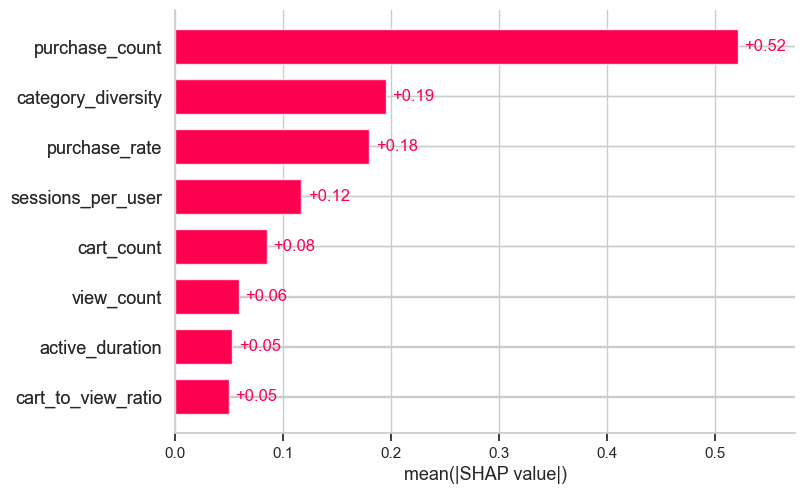

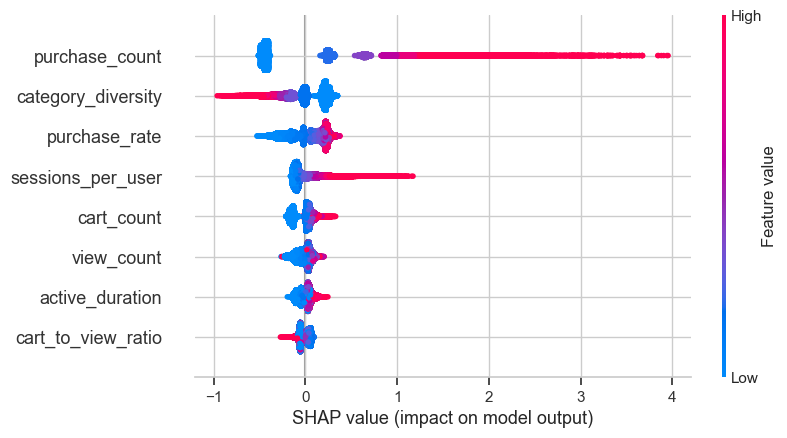

In [30]:
# XGBoost CLV Modelling on Behavioural Features

# ── 1. Feature Scaling ───────────────────────────────────────────────
def scale_behavioural_features(df, exclude_cols=['user_id']):
    """Scale numeric features using MinMaxScaler."""
    features = [col for col in df.columns 
                if col not in exclude_cols 
                and pd.api.types.is_numeric_dtype(df[col])]
    scaler = MinMaxScaler()
    df_scaled = df.copy()
    df_scaled[features] = scaler.fit_transform(df[features])
    print(f"Scaled {len(features)} features: {features}")
    return df_scaled, scaler

beh_df_scaled, scaler_beh = scale_behavioural_features(beh_df)

# ── 2. XGBoost Model Training ────────────────────────────────────────
def train_xgboost_on_behavioural(df_scaled, target_df):
    """Train XGBoost on behavioural features using CLV target from trans_df."""

    # Merge scaled behavioural features with target from trans_df
    df_model = df_scaled.merge(
        target_df[['user_id', 'total_purchase_amount']], 
        on='user_id', 
        how='inner'
    )

    # Features — drop user_id and target
    X = df_model.drop(columns=['user_id', 'total_purchase_amount'])
    X = X.select_dtypes(include=['number'])

    # Log-transform target to handle right skew
    y = np.log1p(df_model['total_purchase_amount'])

    print(f"Training samples  : {X.shape[0]:,} users")
    print(f"Number of features: {X.shape[1]}")
    print(f"Features used     : {list(X.columns)}")

    # 80/20 train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ── Model Definition ─────────────────────────────────────────────
    model = XGBRegressor(
        objective        = 'reg:squarederror',
        n_estimators     = 150,
        max_depth        = 4,
        learning_rate    = 0.1,
        colsample_bytree = 0.7,
        reg_lambda       = 2,
        random_state     = 42,
        verbosity        = 0
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    # ── Evaluation ───────────────────────────────────────────────────
    y_pred = np.expm1(model.predict(X_test))
    y_true = np.expm1(y_test)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # Manual RMSE for compatibility
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print("\nBehavioural XGBoost CLV Model Performance:")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")

    return model, X_train, X_test, y_true, y_pred

# Pass scaled behavioural features and trans_df as target source
model_beh, X_beh_train, X_beh_test, y_beh_true, y_beh_pred = train_xgboost_on_behavioural(beh_df_scaled, trans_df)

# ── 3. SHAP Feature Importance ───────────────────────────────────────
explainer   = shap.Explainer(model_beh, X_beh_train)
shap_values = explainer(X_beh_train)

print("\nSHAP Feature Importance (Top 10):")
shap.plots.bar(shap_values, max_display=10)
shap.plots.beeswarm(shap_values, max_display=10)

In [31]:
# Train Multiple Supervised Models on Behavioural Features

def train_multiple_models_on_behavioural(df_scaled, target_df):
    """Train Decision Tree, Gradient Boosting and Random Forest on behavioural features."""

    # Merge scaled behavioural features with CLV target from trans_df
    df_model = df_scaled.merge(
        target_df[['user_id', 'total_purchase_amount']],
        on='user_id',
        how='inner'
    )

    # Features — drop identifier and target
    X = df_model.drop(columns=['user_id', 'total_purchase_amount'])
    X = X.select_dtypes(include=['number'])

    # Log-transform target to handle right skew
    y = np.log1p(df_model['total_purchase_amount'])

    print(f"Training samples  : {X.shape[0]:,} users")
    print(f"Number of features: {X.shape[1]}")
    print(f"Features used     : {list(X.columns)}")

    # 80/20 train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ── Model Definitions ────────────────────────────────────────────
    models = {
        'Decision Tree'     : DecisionTreeRegressor(max_depth=10, random_state=42),
        'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100, random_state=42),
        'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42)
    }

    results = {}

    for model_name, model in models.items():
        print(f"\nTraining {model_name}...")
        model.fit(X_train, y_train)

        # Inverse log-transform for interpretable metrics
        y_pred = np.expm1(model.predict(X_test))
        y_true = np.expm1(y_test)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)

        results[model_name] = {
            'RMSE' : rmse,
            'MAE'  : mae,
            'R2'   : r2,
            'model': model
        }

        print(f"  RMSE : {rmse:.4f}")
        print(f"  MAE  : {mae:.4f}")
        print(f"  R²   : {r2:.4f}")

    return results, X_train, X_test

# Pass both scaled behavioural features and trans_df as target source
model_results, X_beh_train, X_beh_test = train_multiple_models_on_behavioural(beh_df_scaled, trans_df)

# ── Model Comparison Table ───────────────────────────────────────────
comparison_df = pd.DataFrame({
    model_name: {
        metric: value 
        for metric, value in metrics.items() 
        if metric != 'model'
    } 
    for model_name, metrics in model_results.items()
}).T

print("\n=== Behavioural Model Comparison ===")
print(comparison_df.to_string())

Training samples  : 263,380 users
Number of features: 8
Features used     : ['sessions_per_user', 'active_duration', 'category_diversity', 'cart_count', 'purchase_count', 'view_count', 'cart_to_view_ratio', 'purchase_rate']

Training Decision Tree...
  RMSE : 1706.8224
  MAE  : 482.9355
  R²   : 0.4162

Training Gradient Boosting...
  RMSE : 1568.8100
  MAE  : 466.1754
  R²   : 0.5068

Training Random Forest...
  RMSE : 1510.9339
  MAE  : 487.4869
  R²   : 0.5425

=== Behavioural Model Comparison ===
                          RMSE         MAE        R2
Decision Tree      1706.822361  482.935498  0.416197
Gradient Boosting  1568.809982  466.175378  0.506792
Random Forest      1510.933863  487.486928  0.542511


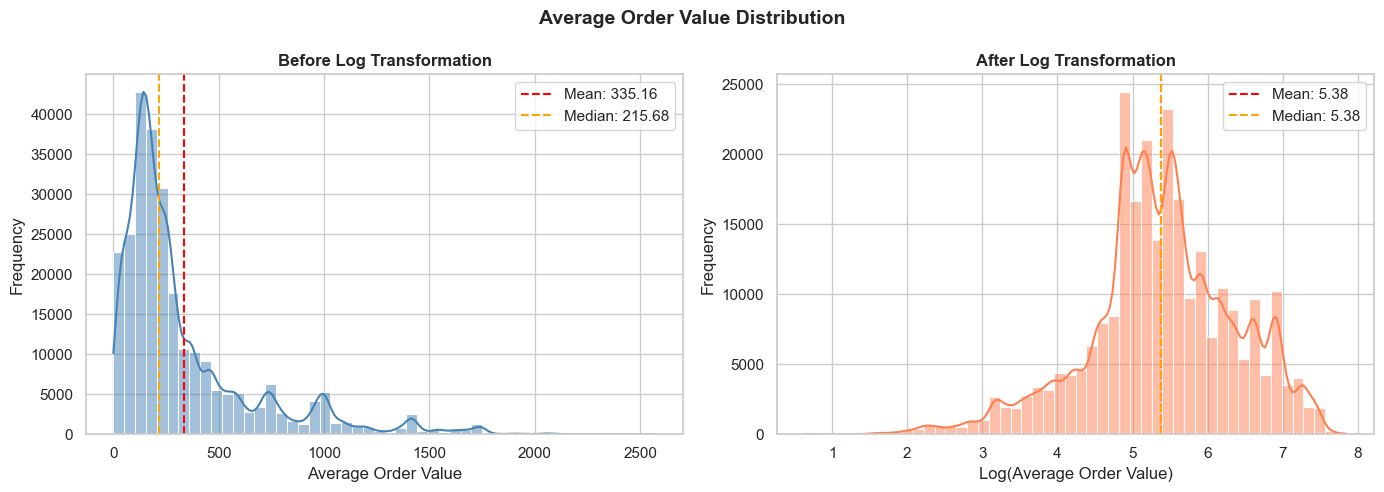

In [32]:
# Visual inspection for Average Order Value — Before and After Log Transformation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Average Order Value Distribution', fontsize=14, fontweight='bold')

# ── Before Log Transformation ────────────────────────────────────────
sns.histplot(hybrid_df['avg_order_value'], kde=True, color='steelblue', 
             bins=50, ax=axes[0])
axes[0].set_title('Before Log Transformation', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Order Value')
axes[0].set_ylabel('Frequency')
axes[0].axvline(hybrid_df['avg_order_value'].mean(), color='red', 
                linestyle='--', linewidth=1.5, label=f"Mean: {hybrid_df['avg_order_value'].mean():.2f}")
axes[0].axvline(hybrid_df['avg_order_value'].median(), color='orange', 
                linestyle='--', linewidth=1.5, label=f"Median: {hybrid_df['avg_order_value'].median():.2f}")
axes[0].legend()

# ── Apply Log Transformation ─────────────────────────────────────────
hybrid_df['avg_order_value_log'] = np.log1p(hybrid_df['avg_order_value'])

# ── After Log Transformation ─────────────────────────────────────────
sns.histplot(hybrid_df['avg_order_value_log'], kde=True, color='coral', 
             bins=50, ax=axes[1])
axes[1].set_title('After Log Transformation', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log(Average Order Value)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(hybrid_df['avg_order_value_log'].mean(), color='red', 
                linestyle='--', linewidth=1.5, label=f"Mean: {hybrid_df['avg_order_value_log'].mean():.2f}")
axes[1].axvline(hybrid_df['avg_order_value_log'].median(), color='orange', 
                linestyle='--', linewidth=1.5, label=f"Median: {hybrid_df['avg_order_value_log'].median():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

=== Before Outlier Removal ===
  Total users    : 263,380
  Mean CLV       : $773.97
  Median CLV     : $287.97
  Max CLV        : $265569.52
  99th Percentile: $7460.11


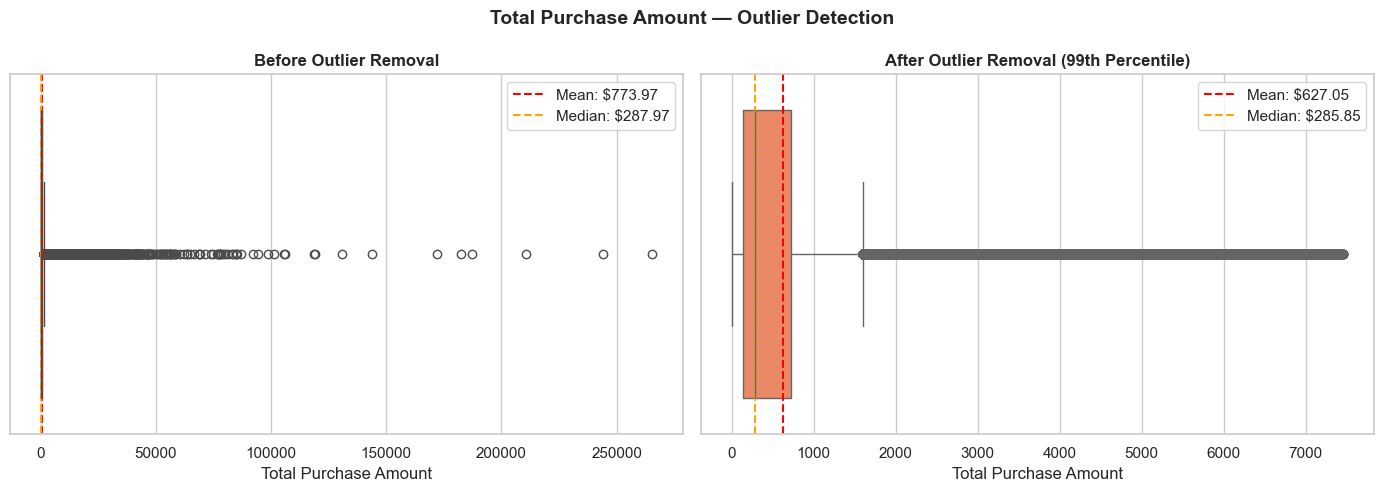


=== After Outlier Removal ===
  Total users    : 260,746
  Mean CLV       : $627.05
  Median CLV     : $285.85
  Max CLV        : $7459.80
  Threshold used : $7460.11
  Users removed  : 260,746 remaining after filtering


In [33]:
# Outlier Detection for Total Purchase Amount (CLV Target)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Total Purchase Amount — Outlier Detection', fontsize=14, fontweight='bold')

# ── Before Filtering ─────────────────────────────────────────────────
sns.boxplot(x=hybrid_df['total_purchase_amount'], color='steelblue', ax=axes[0])
axes[0].set_title('Before Outlier Removal', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Purchase Amount')
axes[0].axvline(hybrid_df['total_purchase_amount'].mean(), color='red',
                linestyle='--', linewidth=1.5, label=f"Mean: ${hybrid_df['total_purchase_amount'].mean():.2f}")
axes[0].axvline(hybrid_df['total_purchase_amount'].median(), color='orange',
                linestyle='--', linewidth=1.5, label=f"Median: ${hybrid_df['total_purchase_amount'].median():.2f}")
axes[0].legend()

# Print summary stats before filtering
print("=== Before Outlier Removal ===")
print(f"  Total users    : {len(hybrid_df):,}")
print(f"  Mean CLV       : ${hybrid_df['total_purchase_amount'].mean():.2f}")
print(f"  Median CLV     : ${hybrid_df['total_purchase_amount'].median():.2f}")
print(f"  Max CLV        : ${hybrid_df['total_purchase_amount'].max():.2f}")
print(f"  99th Percentile: ${hybrid_df['total_purchase_amount'].quantile(0.99):.2f}")

# ── Apply 99th Percentile Threshold ──────────────────────────────────
threshold = hybrid_df['total_purchase_amount'].quantile(0.99)
hybrid_df = hybrid_df[hybrid_df['total_purchase_amount'] <= threshold]

# ── After Filtering ──────────────────────────────────────────────────
sns.boxplot(x=hybrid_df['total_purchase_amount'], color='coral', ax=axes[1])
axes[1].set_title('After Outlier Removal (99th Percentile)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Purchase Amount')
axes[1].axvline(hybrid_df['total_purchase_amount'].mean(), color='red',
                linestyle='--', linewidth=1.5, label=f"Mean: ${hybrid_df['total_purchase_amount'].mean():.2f}")
axes[1].axvline(hybrid_df['total_purchase_amount'].median(), color='orange',
                linestyle='--', linewidth=1.5, label=f"Median: ${hybrid_df['total_purchase_amount'].median():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print summary stats after filtering
print("\n=== After Outlier Removal ===")
print(f"  Total users    : {len(hybrid_df):,}")
print(f"  Mean CLV       : ${hybrid_df['total_purchase_amount'].mean():.2f}")
print(f"  Median CLV     : ${hybrid_df['total_purchase_amount'].median():.2f}")
print(f"  Max CLV        : ${hybrid_df['total_purchase_amount'].max():.2f}")
print(f"  Threshold used : ${threshold:.2f}")
print(f"  Users removed  : {len(hybrid_df):,} remaining after filtering")

## Customer segmentation by k-means clustering

All 6 clustering features found.


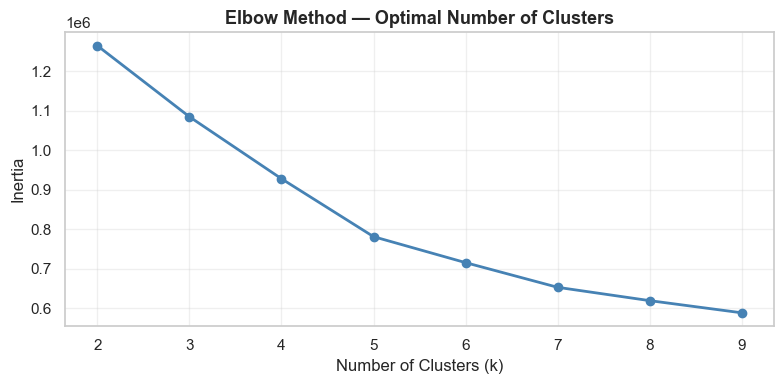


Clustering complete.
Segment distribution:
customer_segment
0     36565
1     11700
2     22239
3    190242
Name: count, dtype: int64

=== Cluster Profile Summary ===
                  num_purchases  avg_order_value  total_views  total_carts  recency_days  category_diversity  total_purchase_amount
customer_segment                                                                                                                   
0                          1.69          1011.06        15.81         1.68         13.65                1.73                1661.82
1                          8.49           311.86        54.10        11.99          8.29                3.25                2476.68
2                          2.09           217.15       107.60         2.51         12.83                7.74                 481.43
3                          1.50           212.79        16.46         1.55         14.22                1.89                 331.44


In [34]:
# Customer Segmentation via KMeans Clustering

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "8"

# ── 1. Feature Selection for Clustering ─────────────────────────────
cluster_features = [
    'num_purchases', 
    'avg_order_value', 
    'total_views',
    'total_carts', 
    'recency_days', 
    'category_diversity'
]

# Verify all features exist before clustering
missing = [f for f in cluster_features if f not in hybrid_df.columns]
if missing:
    print(f"Warning: Missing features: {missing}")
else:
    print(f"All {len(cluster_features)} clustering features found.")

# ── 2. Feature Scaling ───────────────────────────────────────────────
# StandardScaler used for clustering — ensures no single feature dominates
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(hybrid_df[cluster_features])

# ── 3. Optimal K Selection via Elbow Method ──────────────────────────
inertia = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 4. KMeans Fitting with k=4 ───────────────────────────────────────
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
hybrid_df['customer_segment'] = kmeans.fit_predict(X_cluster)

print(f"\nClustering complete.")
print(f"Segment distribution:\n{hybrid_df['customer_segment'].value_counts().sort_index()}")

# ── 5. Cluster Profile Summary ───────────────────────────────────────
cluster_summary = hybrid_df.groupby('customer_segment')[cluster_features + ['total_purchase_amount']].mean().round(2)
print("\n=== Cluster Profile Summary ===")
print(cluster_summary.to_string())

## Hybrid Segemented XGBoost Modelling

In [35]:
# Hybrid Modelling — XGBoost per Customer Segment

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── 1. Feature Preparation ───────────────────────────────────────────
def clean_features(df, target='total_purchase_amount'):
    """Drop identifier and non-numeric columns, return X and y."""
    X = df.drop(columns=['user_id', target, 'top_category', 
                         'customer_segment'], errors='ignore')
    y = np.log1p(df[target])  # Log-transform target to handle right skew
    return X.select_dtypes(include=['number']), y

# ── 2. Segment-wise XGBoost Training ────────────────────────────────
def train_hybrid_model_by_segment(df, target='total_purchase_amount'):
    """Train an XGBoost model independently per customer segment."""
    
    metrics  = {}
    models   = {}
    segments = sorted(df['customer_segment'].unique())

    print("=" * 50)
    print("Hybrid XGBoost — Segment-wise CLV Modelling")
    print("=" * 50)

    for seg in segments:
        df_seg = df[df['customer_segment'] == seg].copy()

        # Skip segments with insufficient data for reliable modelling
        if len(df_seg) < 50:
            print(f"\nSegment {seg} skipped — insufficient samples ({len(df_seg)})")
            continue

        X, y = clean_features(df_seg, target)

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # ── Model Definition ─────────────────────────────────────────
        model = XGBRegressor(
            objective        = 'reg:squarederror',
            n_estimators     = 150,
            max_depth        = 4,
            learning_rate    = 0.1,
            colsample_bytree = 0.7,
            reg_lambda       = 2,
            random_state     = 42,
            verbosity        = 0
        )

        model.fit(X_train, y_train, 
                  eval_set=[(X_test, y_test)], 
                  verbose=False)

        # Inverse log-transform for interpretable metrics
        y_pred = np.expm1(model.predict(X_test))
        y_true = np.expm1(y_test)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)

        metrics[seg] = {
            'Segment Size' : len(df_seg),
            'RMSE'         : round(rmse, 4),
            'MAE'          : round(mae, 4),
            'R2'           : round(r2, 4)
        }
        models[seg] = model

        print(f"\nSegment {seg} ({len(df_seg):,} users)")
        print(f"  RMSE : {rmse:.4f}")
        print(f"  MAE  : {mae:.4f}")
        print(f"  R²   : {r2:.4f}")

    # ── Segment Comparison Table ─────────────────────────────────────
    print("\n" + "=" * 50)
    print("Segment Performance Summary")
    print("=" * 50)
    summary_df = pd.DataFrame(metrics).T
    print(summary_df.to_string())

    return metrics, models

# ── 3. Run Hybrid Model ──────────────────────────────────────────────
segment_metrics, segment_models = train_hybrid_model_by_segment(hybrid_df)

Hybrid XGBoost — Segment-wise CLV Modelling

Segment 0 (36,565 users)
  RMSE : 32.9635
  MAE  : 15.1941
  R²   : 0.9992

Segment 1 (11,700 users)
  RMSE : 102.0880
  MAE  : 57.6322
  R²   : 0.9969

Segment 2 (22,239 users)
  RMSE : 32.9049
  MAE  : 11.6589
  R²   : 0.9977

Segment 3 (190,242 users)
  RMSE : 8.7239
  MAE  : 4.1485
  R²   : 0.9994

Segment Performance Summary
   Segment Size      RMSE      MAE      R2
0       36565.0   32.9635  15.1941  0.9992
1       11700.0  102.0880  57.6322  0.9969
2       22239.0   32.9049  11.6589  0.9977
3      190242.0    8.7239   4.1485  0.9994


Hybrid XGBoost — Segment-wise CLV Modelling

Segment 0 (36,565 users)
  RMSE : 32.9635
  MAE  : 15.1941
  R²   : 0.9992

Segment 1 (11,700 users)
  RMSE : 102.0880
  MAE  : 57.6322
  R²   : 0.9969

Segment 2 (22,239 users)
  RMSE : 32.9049
  MAE  : 11.6589
  R²   : 0.9977

Segment 3 (190,242 users)
  RMSE : 8.7239
  MAE  : 4.1485
  R²   : 0.9994

Segment Performance Summary
   Segment Size      RMSE      MAE      R2
0       36565.0   32.9635  15.1941  0.9992
1       11700.0  102.0880  57.6322  0.9969
2       22239.0   32.9049  11.6589  0.9977
3      190242.0    8.7239   4.1485  0.9994


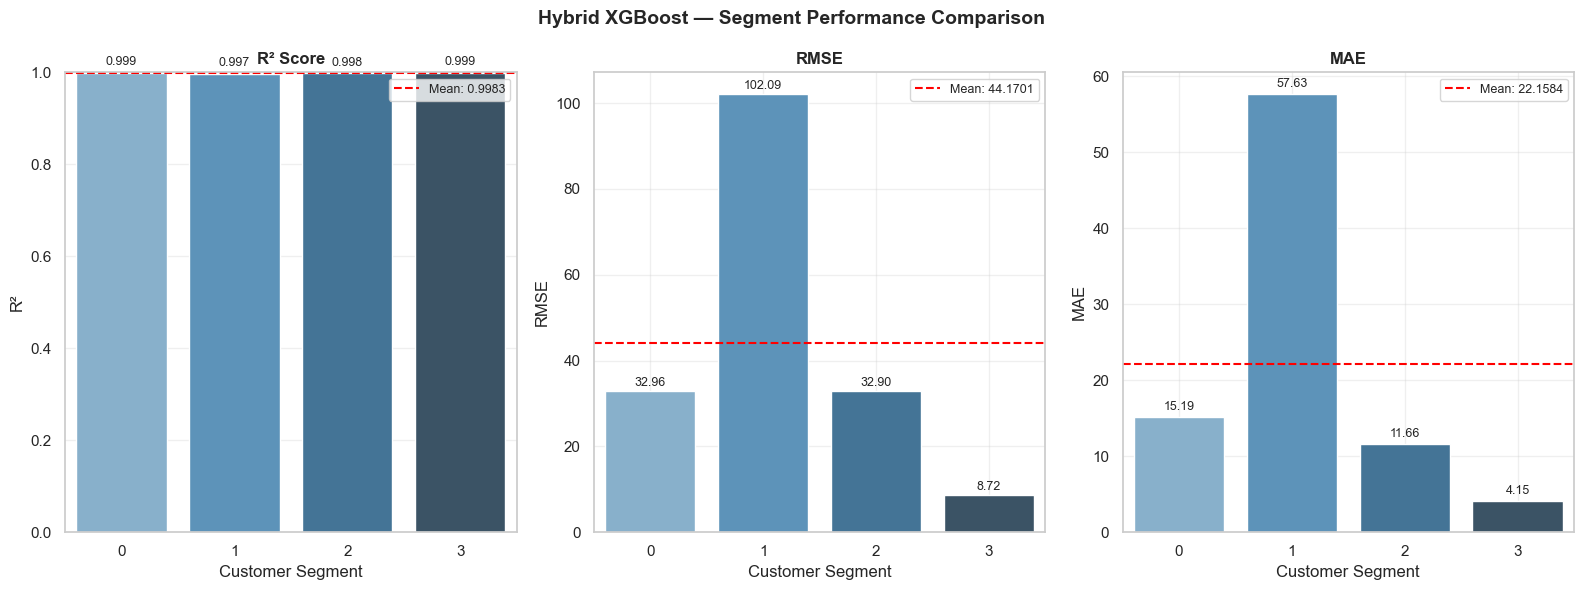


=== Segment Performance Summary ===
Segment     R2     RMSE     MAE
      0 0.9992  32.9635 15.1941
      1 0.9969 102.0880 57.6322
      2 0.9977  32.9049 11.6589
      3 0.9994   8.7239  4.1485


In [36]:
# Hybrid Model — Performance Visualisation by Segment

def plot_hybrid_performance(metrics):
    """Plot R², RMSE and MAE performance across customer segments."""

    # Build results dataframe
    df_results = pd.DataFrame(metrics).T.reset_index()
    df_results.rename(columns={'index': 'Segment'}, inplace=True)
    df_results['Segment'] = df_results['Segment'].astype(str)

    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    fig.suptitle('Hybrid XGBoost — Segment Performance Comparison', 
                 fontsize=14, fontweight='bold')

    palette = sns.color_palette('Blues_d', len(df_results))

    # ── R² Score ────────────────────────────────────────────────────
    sns.barplot(x='Segment', y='R2', data=df_results, 
                palette=palette, ax=axes[0])
    axes[0].set_title('R² Score', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Customer Segment')
    axes[0].set_ylabel('R²')
    axes[0].set_ylim(0, 1)
    axes[0].axhline(df_results['R2'].mean(), color='red', linestyle='--', 
                    linewidth=1.5, label=f"Mean: {df_results['R2'].mean():.4f}")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    for bar in axes[0].patches:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)

    # ── RMSE ─────────────────────────────────────────────────────────
    sns.barplot(x='Segment', y='RMSE', data=df_results, 
                palette=palette, ax=axes[1])
    axes[1].set_title('RMSE', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Customer Segment')
    axes[1].set_ylabel('RMSE')
    axes[1].axhline(df_results['RMSE'].mean(), color='red', linestyle='--',
                    linewidth=1.5, label=f"Mean: {df_results['RMSE'].mean():.4f}")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)
    for bar in axes[1].patches:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=9)

    # ── MAE ──────────────────────────────────────────────────────────
    sns.barplot(x='Segment', y='MAE', data=df_results, 
                palette=palette, ax=axes[2])
    axes[2].set_title('MAE', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Customer Segment')
    axes[2].set_ylabel('MAE')
    axes[2].axhline(df_results['MAE'].mean(), color='red', linestyle='--',
                    linewidth=1.5, label=f"Mean: {df_results['MAE'].mean():.4f}")
    axes[2].legend(fontsize=9)
    axes[2].grid(True, alpha=0.3)
    for bar in axes[2].patches:
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    # ── Summary Table ────────────────────────────────────────────────
    print("\n=== Segment Performance Summary ===")
    print(df_results[['Segment', 'R2', 'RMSE', 'MAE']].to_string(index=False))

    return df_results

# Run hybrid model and plot results
segment_metrics, segment_models = train_hybrid_model_by_segment(hybrid_df)
df_hybrid_results = plot_hybrid_performance(segment_metrics)

Hybrid XGBoost — Segment-wise CLV Modelling

Segment 0 (36,565 users)
  RMSE : 32.9635
  MAE  : 15.1941
  R²   : 0.9992

Segment 1 (11,700 users)
  RMSE : 102.0880
  MAE  : 57.6322
  R²   : 0.9969

Segment 2 (22,239 users)
  RMSE : 32.9049
  MAE  : 11.6589
  R²   : 0.9977

Segment 3 (190,242 users)
  RMSE : 8.7239
  MAE  : 4.1485
  R²   : 0.9994

Segment Performance Summary
   Segment Size      RMSE      MAE      R2
0       36565.0   32.9635  15.1941  0.9992
1       11700.0  102.0880  57.6322  0.9969
2       22239.0   32.9049  11.6589  0.9977
3      190242.0    8.7239   4.1485  0.9994

Benchmark Summary
                       RMSE       MAE      R2
Model                                        
Segmented XGBoost   44.1701   22.1584  0.9983
Mean Baseline      917.3879  570.0012 -0.0001
Linear Regression  437.1086  216.7460  0.7730


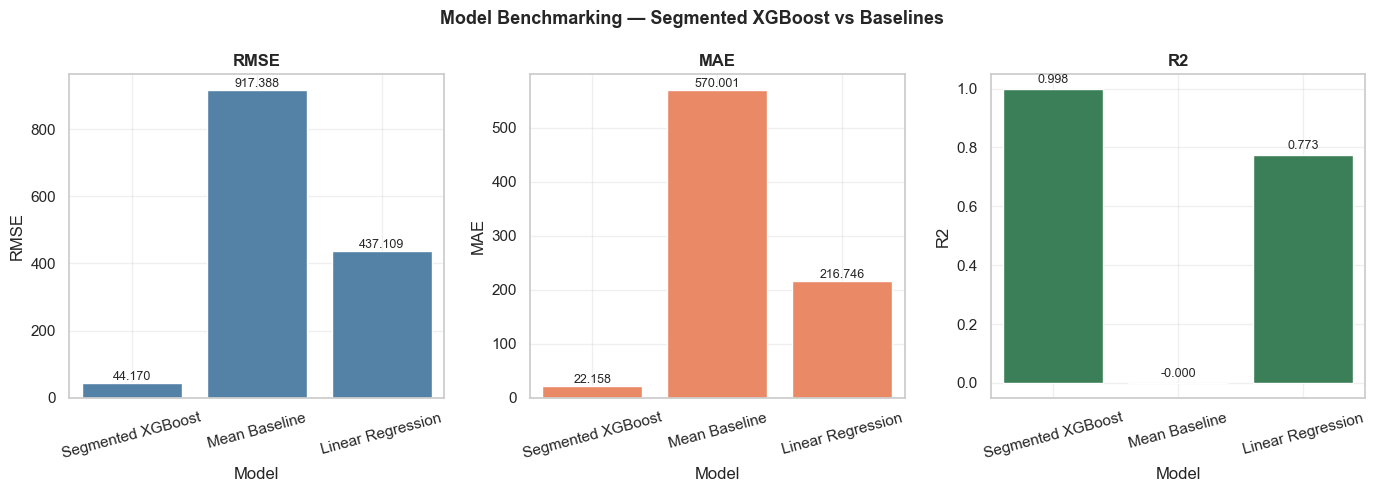

In [37]:
# Run and Benchmark — Segmented XGBoost vs Baseline Models

from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
import numpy as np
import pandas as pd

# ── 1. Run Segmented Hybrid Model ────────────────────────────────────
segment_metrics, segment_models = train_hybrid_model_by_segment(hybrid_df)

# ── 2. Average Metrics Across Segments ──────────────────────────────
seg_rmse = np.mean([v['RMSE'] for v in segment_metrics.values()])
seg_mae  = np.mean([v['MAE']  for v in segment_metrics.values()])
seg_r2   = np.mean([v['R2']   for v in segment_metrics.values()])

benchmark_metrics = {}
benchmark_metrics['Segmented XGBoost'] = {
    'RMSE' : round(seg_rmse, 4),
    'MAE'  : round(seg_mae,  4),
    'R2'   : round(seg_r2,   4)
}

# ── 3. Baseline Models for Comparison ───────────────────────────────
# Prepare full dataset for baseline training
X_full, y_full = clean_features(hybrid_df)
y_full_raw = hybrid_df['total_purchase_amount']  # Unlogged for fair comparison

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_full, y_full_raw, test_size=0.2, random_state=42
)

# Mean baseline — predicts the mean for every user
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_b, y_train_b)
y_pred_dummy = dummy.predict(X_test_b)

benchmark_metrics['Mean Baseline'] = {
    'RMSE' : round(np.sqrt(mean_squared_error(y_test_b, y_pred_dummy)), 4),
    'MAE'  : round(mean_absolute_error(y_test_b, y_pred_dummy), 4),
    'R2'   : round(r2_score(y_test_b, y_pred_dummy), 4)
}

# Linear Regression baseline
lr = LinearRegression()
lr.fit(X_train_b, y_train_b)
y_pred_lr = lr.predict(X_test_b)

benchmark_metrics['Linear Regression'] = {
    'RMSE' : round(np.sqrt(mean_squared_error(y_test_b, y_pred_lr)), 4),
    'MAE'  : round(mean_absolute_error(y_test_b, y_pred_lr), 4),
    'R2'   : round(r2_score(y_test_b, y_pred_lr), 4)
}

# ── 4. Benchmark Summary Table ───────────────────────────────────────
benchmark_df = pd.DataFrame(benchmark_metrics).T
benchmark_df.index.name = 'Model'

print("\n" + "=" * 50)
print("Benchmark Summary")
print("=" * 50)
print(benchmark_df.to_string())

# ── 5. Visual Comparison ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Model Benchmarking — Segmented XGBoost vs Baselines',
             fontsize=13, fontweight='bold')

metrics_to_plot = ['RMSE', 'MAE', 'R2']
colors = ['steelblue', 'coral', 'seagreen']

for ax, metric, color in zip(axes, metrics_to_plot, colors):
    sns.barplot(x=benchmark_df.index, y=benchmark_df[metric],
                palette=[color] * len(benchmark_df), ax=ax)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=15)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Feature Importance

Training SHAP Models per Segment

Segment 0 (36,565 users)
  RMSE : 32.9635
  MAE  : 15.1941
  R²   : 0.9992

Segment 1 (11,700 users)
  RMSE : 102.0880
  MAE  : 57.6322
  R²   : 0.9969

Segment 2 (22,239 users)
  RMSE : 32.9049
  MAE  : 11.6589
  R²   : 0.9977

Segment 3 (190,242 users)
  RMSE : 8.7239
  MAE  : 4.1485
  R²   : 0.9994

SHAP Feature Importance per Segment

Segment 0 — Top 10 Feature Contributions


100%|===================| 29199/29252 [02:20<00:00]        

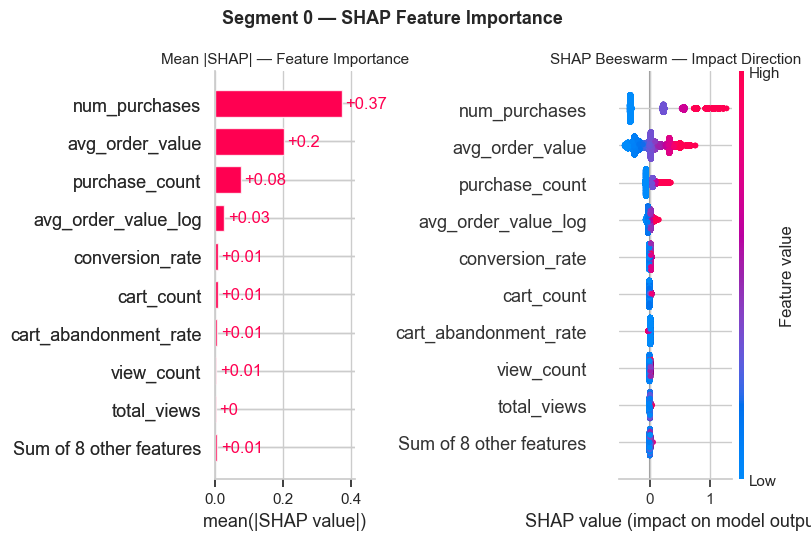


Segment 1 — Top 10 Feature Contributions


 96%|=================== | 9019/9360 [00:45<00:01]       

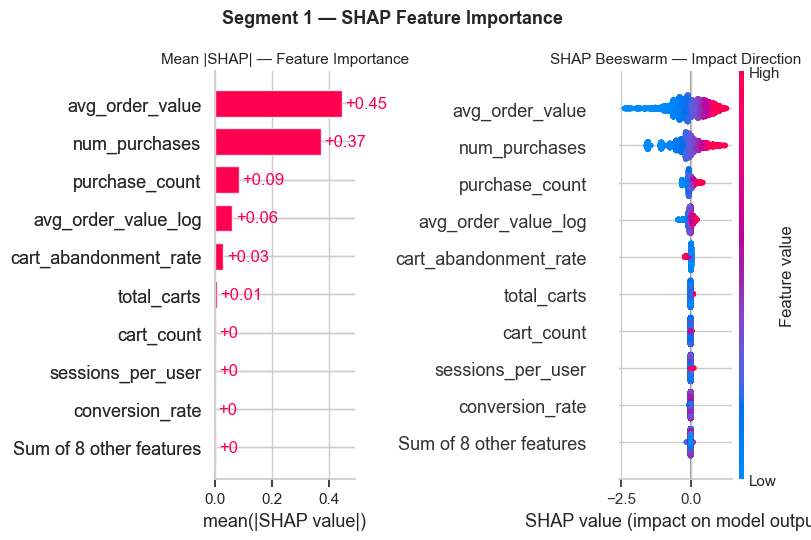


Segment 2 — Top 10 Feature Contributions


 98%|===================| 17448/17791 [00:35<00:00]        

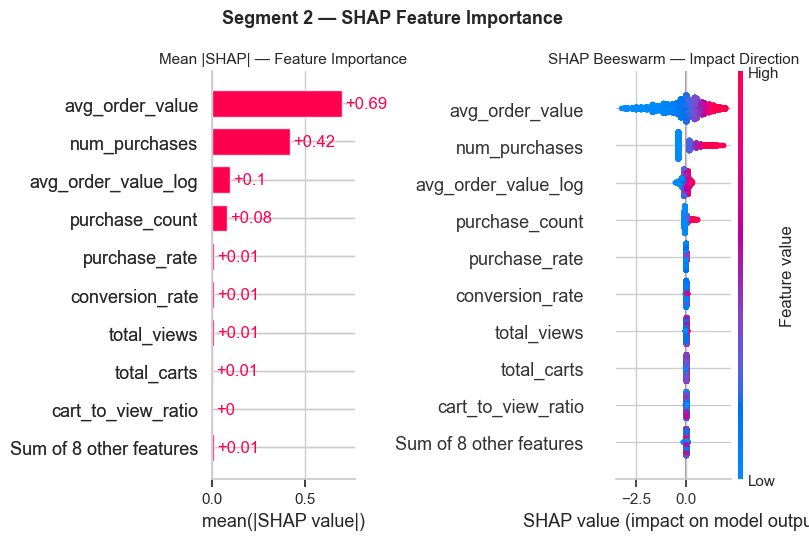


Segment 3 — Top 10 Feature Contributions


100%|===================| 151884/152193 [04:59<00:00]        

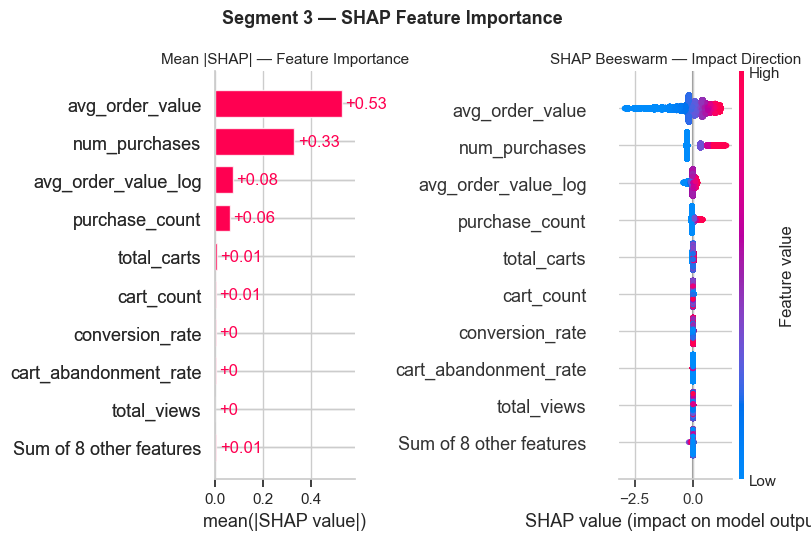

In [38]:
# SHAP Feature Importance per Customer Segment

# ── 1. Train Segment-wise Models and Store ───────────────────────────
segment_models  = {}
X_segments      = {}
segments        = sorted(hybrid_df['customer_segment'].unique())

print("=" * 50)
print("Training SHAP Models per Segment")
print("=" * 50)

for seg in segments:
    df_seg = hybrid_df[hybrid_df['customer_segment'] == seg].copy()

    # Skip segments with insufficient data
    if len(df_seg) < 50:
        print(f"Segment {seg} skipped — insufficient samples ({len(df_seg)})")
        continue

    # Features and log-transformed target
    X = df_seg.drop(columns=['user_id', 'total_purchase_amount', 
                              'top_category', 'customer_segment'], errors='ignore')
    X = X.select_dtypes(include='number')
    y = np.log1p(df_seg['total_purchase_amount'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ── Model Definition ─────────────────────────────────────────────
    model = XGBRegressor(
        objective        = 'reg:squarederror',
        n_estimators     = 150,
        max_depth        = 4,
        learning_rate    = 0.1,
        colsample_bytree = 0.7,
        reg_lambda       = 2,
        random_state     = 42,
        verbosity        = 0
    )

    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

    # Evaluation
    y_pred = np.expm1(model.predict(X_test))
    y_true = np.expm1(y_test)

    print(f"\nSegment {seg} ({len(df_seg):,} users)")
    print(f"  RMSE : {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
    print(f"  MAE  : {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"  R²   : {r2_score(y_true, y_pred):.4f}")

    segment_models[seg] = model
    X_segments[seg]     = X_train

# ── 2. SHAP Analysis per Segment ─────────────────────────────────────
print("\n" + "=" * 50)
print("SHAP Feature Importance per Segment")
print("=" * 50)

for seg in segments:
    if seg not in segment_models:
        continue

    model   = segment_models[seg]
    X_train = X_segments[seg]

    print(f"\nSegment {seg} — Top 10 Feature Contributions")

    explainer   = shap.Explainer(model, X_train)
    shap_values = explainer(X_train)

    # ── Bar Plot — Mean absolute SHAP values ─────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Segment {seg} — SHAP Feature Importance',
                 fontsize=13, fontweight='bold')

    plt.sca(axes[0])
    shap.plots.bar(shap_values, max_display=10, show=False)
    axes[0].set_title('Mean |SHAP| — Feature Importance', fontsize=11)

    # ── Beeswarm Plot — Direction and magnitude ───────────────────────
    plt.sca(axes[1])
    shap.plots.beeswarm(shap_values, max_display=10, show=False)
    axes[1].set_title('SHAP Beeswarm — Impact Direction', fontsize=11)

    plt.tight_layout()
    plt.show()

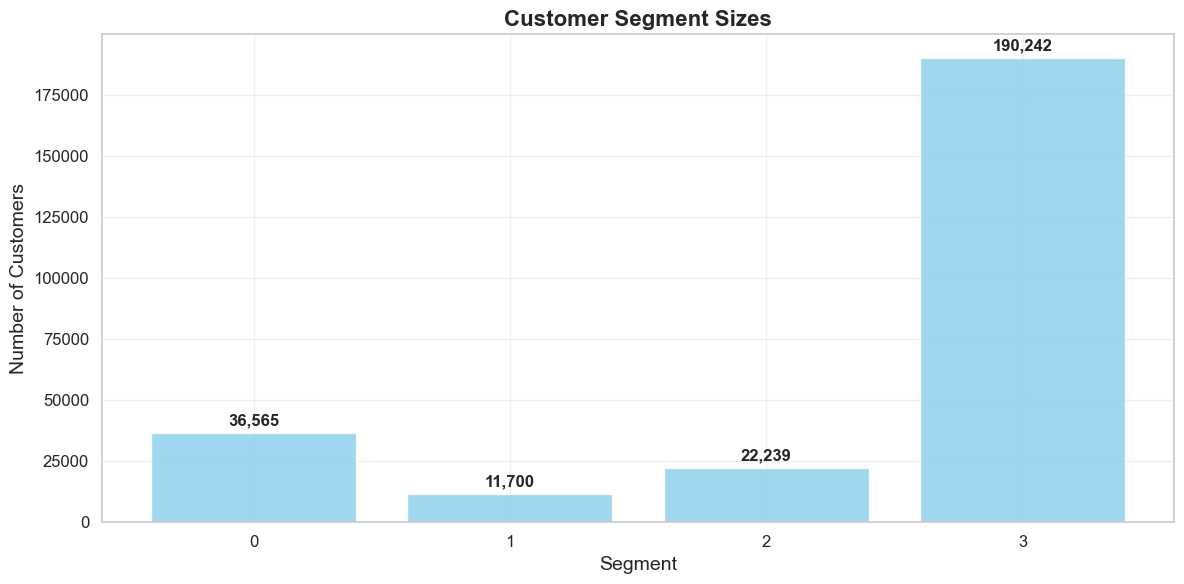

In [39]:
# Customer segment size chart
plt.figure(figsize=(12, 6))

segment_counts = hybrid_df['customer_segment'].value_counts().sort_index()
bars = plt.bar(segment_counts.index, segment_counts.values, color='skyblue', alpha=0.8)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(segment_counts)*0.01,
             f'{height:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title('Customer Segment Sizes', fontsize=16, fontweight='bold')
plt.xlabel('Segment', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14)
plt.xticks(segment_counts.index, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

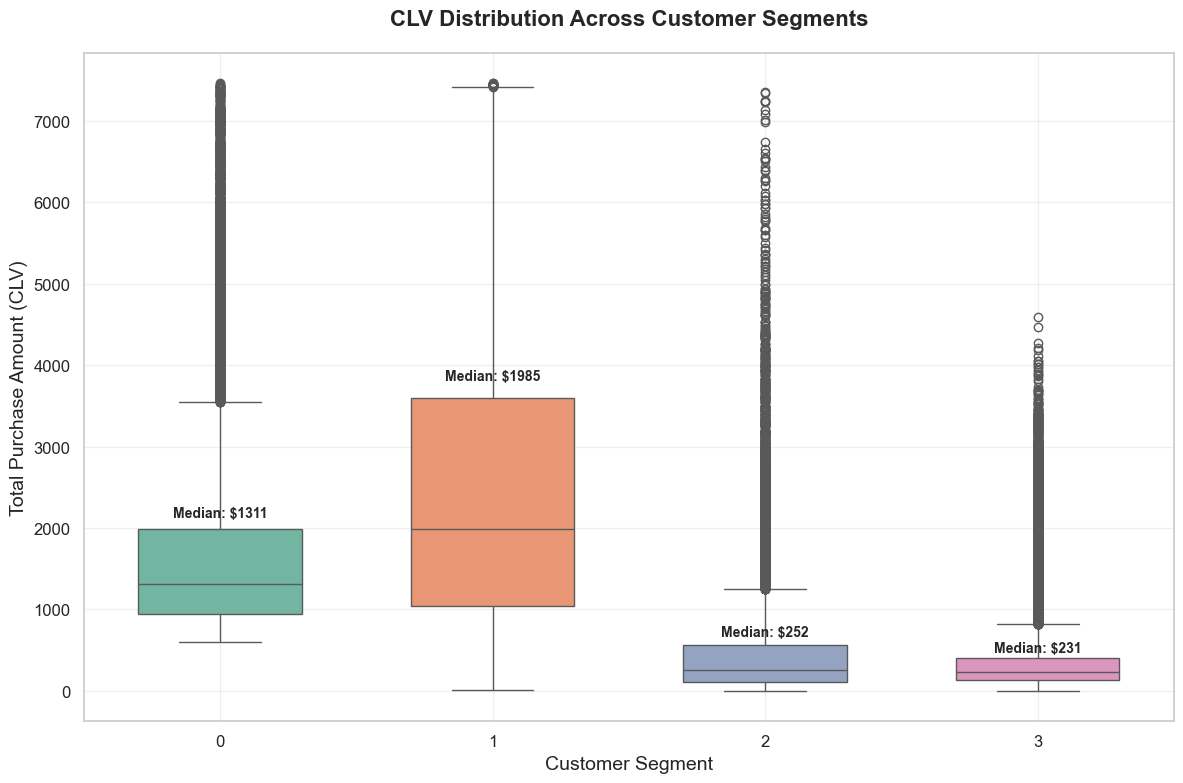

In [40]:
# Visualisation on CLV distributions
plt.figure(figsize=(12, 8))

# Create boxplot with enhanced styling
sns.boxplot(x='customer_segment', y='total_purchase_amount', data=hybrid_df, 
            palette='Set2', width=0.6, showfliers=True)

# Add statistical annotations
segment_stats = hybrid_df.groupby('customer_segment')['total_purchase_amount'].describe()
for i, (seg, stats) in enumerate(segment_stats.iterrows()):
    plt.text(i, stats['75%'] + stats['std']*0.1, 
             f'Median: ${stats["50%"]:.0f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('CLV Distribution Across Customer Segments', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Customer Segment', fontsize=14)
plt.ylabel('Total Purchase Amount (CLV)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
# CLV Classification labels
# Create quantiles to define value segments
q25 = hybrid_df['total_purchase_amount'].quantile(0.25)
q75 = hybrid_df['total_purchase_amount'].quantile(0.75)

print(f"25th percentile: ${q25:.2f}")
print(f"75th percentile: ${q75:.2f}")

# Function to classify customers
def classify_customer(clv):
    if clv <= q25:
        return 'Low Value'
    elif clv >= q75:
        return 'High Value'
    else:
        return 'Medium Value'

# Apply classification
hybrid_df['CLV_Category'] = hybrid_df['total_purchase_amount'].apply(classify_customer)

# View distribution
category_counts = hybrid_df['CLV_Category'].value_counts()
print("\nCLV Category Distribution:")
for category, count in category_counts.items():
    percentage = (count / len(hybrid_df)) * 100
    print(f"{category}: {count:,} ({percentage:.1f}%)")

25th percentile: $143.69
75th percentile: $727.65

CLV Category Distribution:
Medium Value: 130,367 (50.0%)
High Value: 65,192 (25.0%)
Low Value: 65,187 (25.0%)


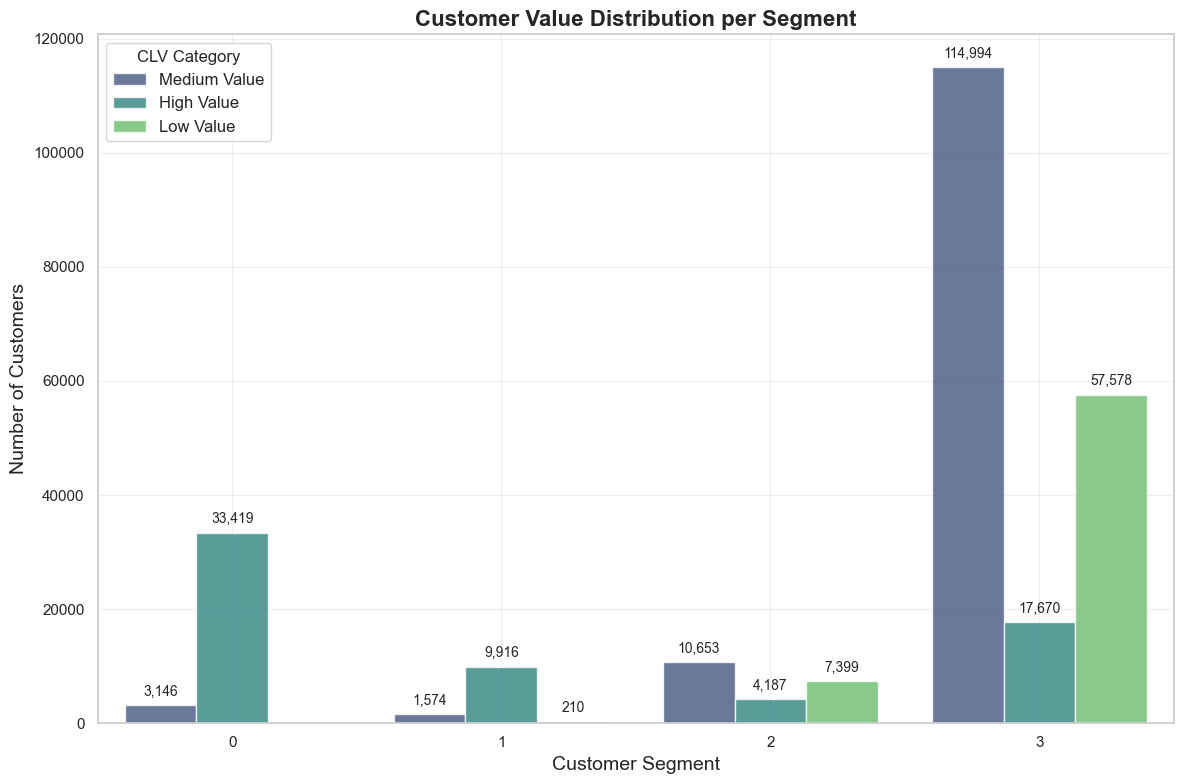

In [47]:
# Visualise CLV segments per customer 
plt.figure(figsize=(12, 8))

# Create countplot with enhanced styling
ax = sns.countplot(data=hybrid_df, x='customer_segment', hue='CLV_Category', 
                   palette='viridis', alpha=0.8)

# Add value labels on bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Only add label if bar exists
        ax.text(p.get_x() + p.get_width()/2, height + max([p.get_height() for p in ax.patches])*0.01,
                f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.title('Customer Value Distribution per Segment', fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14)
plt.legend(title='CLV Category', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Category-specific CLV Modelling with XGBoost

In [50]:
# Category-specific CLV Modelling

# Configuration
feature_columns = [
    'avg_order_value', 'num_purchases', 'total_views', 'total_carts',
    'cart_abandonment_rate', 'conversion_rate', 'recency_days',
    'first_purchase_gap_days', 'category_diversity'
]

# Data Preparation
# Drop missing values
df_category = hybrid_df.dropna(subset=feature_columns + ['total_purchase_amount', 'top_category'])

print(f"Data prepared: {len(df_category)} samples across {df_category['top_category'].nunique()} categories")

# Set minimum required samples
min_samples = 50
category_results = []

# Category-specific modelling
for category in df_category['top_category'].unique():
    cat_df = df_category[df_category['top_category'] == category]

    if len(cat_df) < min_samples:
        print(f"Skipping category '{category}' due to insufficient data ({len(cat_df)} samples).")
        continue

    X = cat_df[feature_columns]
    y = np.log1p(cat_df['total_purchase_amount'])  # log-transform the target to reduce skew

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # XGBoost model with regularisation
    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=100,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42
    )

    model.fit(X_train, y_train)

    # Predict and inverse log
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    y_test_orig = np.expm1(y_test)

    # Evaluation metrics
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    mae = mean_absolute_error(y_test_orig, y_pred)
    r2 = r2_score(y_test_orig, y_pred)

    print(f"Category: {category}")
    print(f"    RMSE: {rmse:.4f}")
    print(f"    MAE : {mae:.4f}")
    print(f"    R² Score: {r2:.4f}")

    category_results.append({
        'Category': category,
        'Samples': len(cat_df),
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })

# Results Summary
category_results_df = pd.DataFrame(category_results).sort_values(by='RMSE').reset_index(drop=True)

print(f"\nProcessed {len(category_results)} categories successfully")
print("\nCategory Performance Summary:")
print(category_results_df)

# Benchmarking Metrics
cat_rmse = category_results_df['RMSE'].mean()
cat_mae = category_results_df['MAE'].mean()
cat_r2 = category_results_df['R2'].mean()

# Store benchmarks in dictionary
benchmark_metrics = {}
benchmark_metrics['Category_XGBoost'] = {
    'RMSE': cat_rmse,
    'MAE': cat_mae,
    'R2': cat_r2
}

# Print Benchmark Summary
print("\nBenchmark Summary (Category-Specific XGBoost):")
print(pd.DataFrame(benchmark_metrics).T)

Data prepared: 260746 samples across 119 categories
Category: electronics.clocks
    RMSE: 84.2623
    MAE : 29.0012
    R² Score: 0.9911
Category: electronics.video.tv
    RMSE: 94.2185
    MAE : 25.1463
    R² Score: 0.9840
Category: appliances.kitchen.oven
    RMSE: 100.0696
    MAE : 22.5812
    R² Score: 0.9224
Category: electronics.smartphone
    RMSE: 52.4257
    MAE : 19.2863
    R² Score: 0.9975
Category: computers.peripherals.mouse
    RMSE: 227.4948
    MAE : 50.1674
    R² Score: 0.7600
Category: computers.notebook
    RMSE: 152.3484
    MAE : 48.2269
    R² Score: 0.9780
Category: furniture.bedroom.bed
    RMSE: 85.6602
    MAE : 29.2848
    R² Score: 0.8575
Category: appliances.kitchen.washer
    RMSE: 90.1222
    MAE : 22.4035
    R² Score: 0.9772
Category: appliances.kitchen.refrigerators
    RMSE: 148.5329
    MAE : 33.2605
    R² Score: 0.9548
Category: computers.peripherals.printer
    RMSE: 48.2010
    MAE : 17.6159
    R² Score: 0.9722
Category: appliances.kitchen.

In [54]:
# Top 10 category results by RMSE
top_table = category_results_df.sort_values(by='RMSE').head(10)
top_table_display = top_table[['Category', 'Samples', 'RMSE', 'R2']].copy()
top_table_display.reset_index(drop=True, inplace=True)

print("="*60)
print("TOP 10 CATEGORY-SPECIFIC CLV MODELS BY RMSE")
print("="*60)
print(f"{'Rank':<5} {'Category':<25} {'Samples':<10} {'RMSE':<10} {'R²':<10}")
print("-"*60)

for i, (idx, row) in enumerate(top_table_display.iterrows(), 1):
    print(f"{i:<5} {row['Category']:<25} {row['Samples']:<10,} {row['RMSE']:<10.4f} {row['R2']:<10.4f}")

print("-"*60)
print(f"Average RMSE: {top_table_display['RMSE'].mean():.4f}")
print(f"Average R²: {top_table_display['R2'].mean():.4f}")
print("="*60)

TOP 10 CATEGORY-SPECIFIC CLV MODELS BY RMSE
Rank  Category                  Samples    RMSE       R²        
------------------------------------------------------------
1     appliances.personal.scales 846        11.3123    0.9733    
2     medicine.tools.tonometer  188        15.2827    0.8500    
3     furniture.bedroom.pillow  59         21.1502    0.7831    
4     appliances.ironing_board  361        24.1934    0.9577    
5     kids.fmcg.diapers         352        25.2271    0.6547    
6     appliances.environment.water_heater 1,815      28.0219    0.9712    
7     furniture.bathroom.toilet 81         30.2367    0.8822    
8     appliances.kitchen.mixer  756        31.9487    0.9626    
9     kids.dolls                100        32.6498    0.9452    
10    furniture.kitchen.table   193        34.0430    0.9227    
------------------------------------------------------------
Average RMSE: 25.4066
Average R²: 0.8903


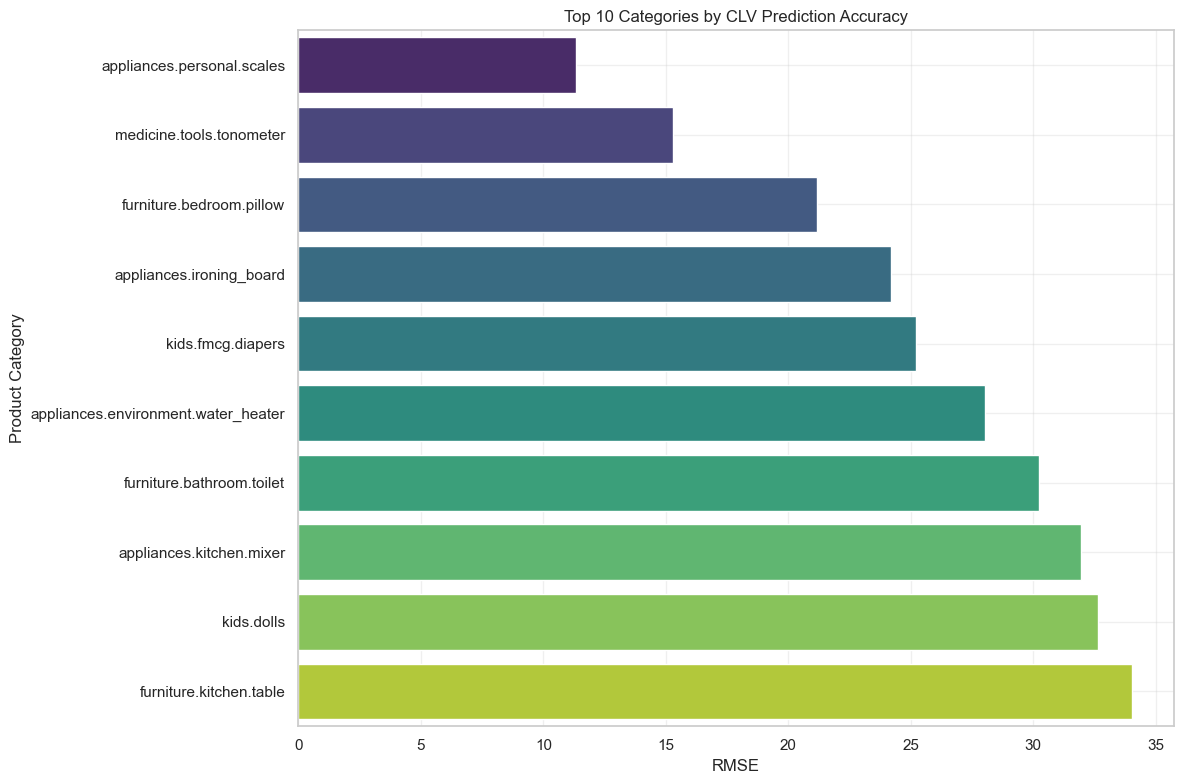

In [57]:
# Bar chart of Top-performing categories
top_categories = category_results_df.sort_values(by='RMSE').head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x='RMSE', y='Category', data=top_categories, palette='viridis')
plt.title('Top 10 Categories by CLV Prediction Accuracy')
plt.xlabel('RMSE')
plt.ylabel('Product Category')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

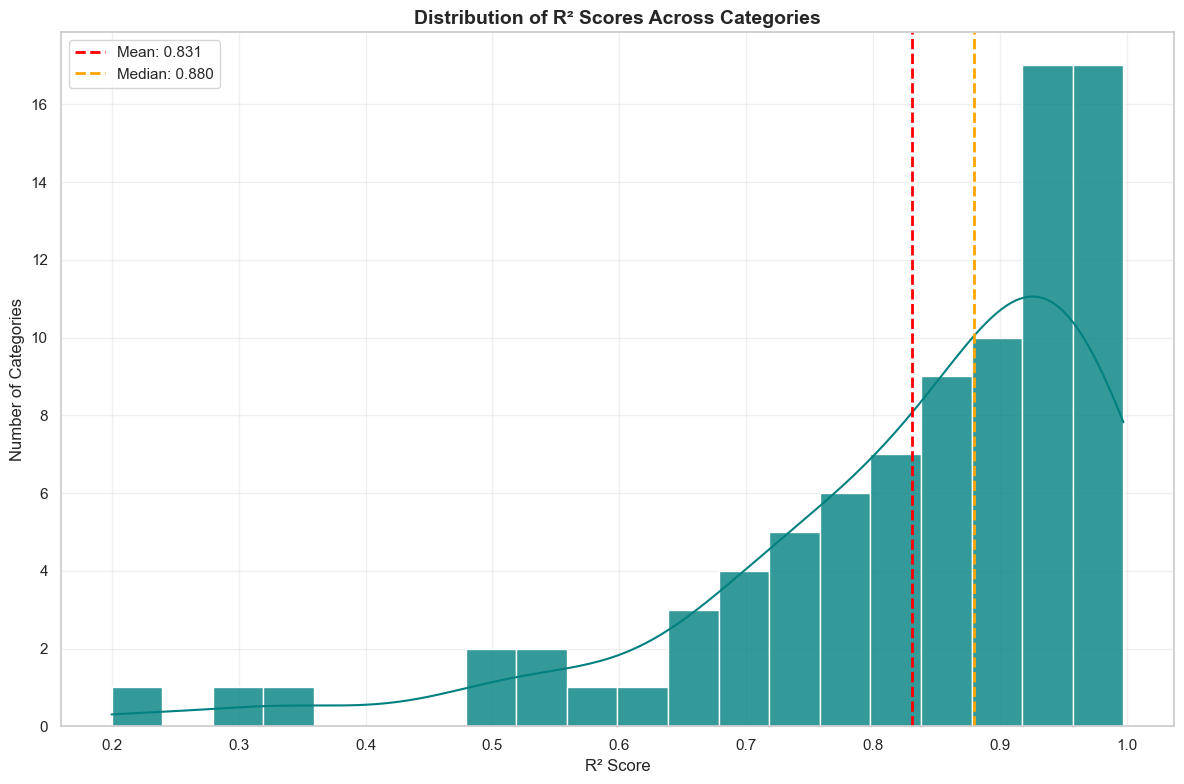

In [60]:
# Distribution of Categories by Predictive Quality

plt.figure(figsize=(12, 8))
sns.histplot(category_results_df['R2'], bins=20, kde=True, color='teal', alpha=0.8)

# Add statistics
mean_r2 = category_results_df['R2'].mean()
median_r2 = category_results_df['R2'].median()

plt.axvline(mean_r2, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_r2:.3f}')
plt.axvline(median_r2, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_r2:.3f}')

plt.title("Distribution of R² Scores Across Categories", fontsize=14, fontweight='bold')
plt.xlabel("R² Score", fontsize=12)
plt.ylabel("Number of Categories", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
# Category Modeling Summary

# Total number of unique categories processed
total_categories = df_category['top_category'].nunique()

# Number of categories included in the model
modeled_categories = category_results_df['Category'].nunique()

# Number of categories skipped
skipped_categories = total_categories - modeled_categories

print("="*60)
print("CATEGORY MODELING SUMMARY")
print("="*60)
print(f"Total product categories in data: {total_categories}")
print(f"Categories modeled (≥ 50 samples): {modeled_categories}")
print(f"Categories skipped due to insufficient data: {skipped_categories}")
print(f"Modeling success rate: {(modeled_categories/total_categories)*100:.1f}%")
print("="*60)

CATEGORY MODELING SUMMARY
Total product categories in data: 119
Categories modeled (≥ 50 samples): 87
Categories skipped due to insufficient data: 32
Modeling success rate: 73.1%


## Session based Sequential behaviour modelling

In [63]:
# Session-based Feature Engineering

# Ensure datetime and relevant filtering
df = df[df['event_type'].isin(['view', 'cart', 'purchase'])].copy()
df['event_time'] = pd.to_datetime(df['event_time'], errors='coerce')

print(f"Data prepared: {len(df):,} events for {df['user_id'].nunique():,} users")

# Create event flags
df['view_flag'] = (df['event_type'] == 'view').astype(int)
df['cart_flag'] = (df['event_type'] == 'cart').astype(int)
df['purchase_flag'] = (df['event_type'] == 'purchase').astype(int)

# Aggregate by user-session
print("Creating session-level features...")
session_df = df.groupby(['user_id', 'user_session']).agg({
    'view_flag': 'sum',
    'cart_flag': 'sum', 
    'purchase_flag': 'sum',
    'event_time': ['min', 'max']
}).reset_index()

# Flatten column names
session_df.columns = ['user_id', 'user_session', 'views', 'carts', 'purchases', 'start_time', 'end_time']

# Calculate session duration
session_df['session_duration_mins'] = (session_df['end_time'] - session_df['start_time']).dt.total_seconds() / 60

# Create session-level features
session_df['cart_abandoned'] = ((session_df['carts'] > 0) & (session_df['purchases'] == 0)).astype(int)
session_df['converted_session'] = (session_df['purchases'] > 0).astype(int)

# Handle negative durations (data issues)
session_df['session_duration_mins'] = session_df['session_duration_mins'].clip(lower=0)

print(f"Created {len(session_df):,} sessions")

# User-level aggregation for LSTM metadata
print("Creating user-level sequential features...")
user_seq_features = session_df.groupby('user_id').agg({
    'views': ['sum', 'mean'],
    'carts': ['sum', 'mean'],
    'purchases': ['sum', 'mean'],
    'session_duration_mins': ['mean', 'std'],
    'cart_abandoned': 'sum',
    'converted_session': 'sum'
}).reset_index()

# Flatten column names properly
user_seq_features.columns = [
    'user_id', 'total_views_seq', 'avg_views_per_session', 
    'total_carts_seq', 'avg_carts_per_session', 'total_purchases_seq', 'avg_purchases_per_session',
    'avg_session_duration', 'std_session_duration',
    'total_cart_abandons', 'converted_sessions'
]

# Fill NaN values for std (single session users)
user_seq_features['std_session_duration'] = user_seq_features['std_session_duration'].fillna(0)

print(f"Created sequential features for {len(user_seq_features):,} users")
print("\nSequential Features Summary:")
print(user_seq_features.describe().round(2))

Data prepared: 26,560,622 events for 2,323,036 users
Creating session-level features...
Created 6,419,912 sessions
Creating user-level sequential features...
Created sequential features for 2,323,036 users

Sequential Features Summary:
            user_id  total_views_seq  avg_views_per_session  total_carts_seq  \
count  2.323036e+06       2323036.00             2323036.00       2323036.00   
mean   5.396376e+08            10.85                   3.38             0.35   
std    1.940827e+07            24.46                   3.71             1.74   
min    3.386938e+07             0.00                   0.00             0.00   
25%    5.194517e+08             2.00                   1.00             0.00   
50%    5.428483e+08             4.00                   2.00             0.00   
75%    5.578019e+08            11.00                   4.00             0.00   
max    5.662807e+08          6043.00                 347.75           494.00   

       avg_carts_per_session  total_purchas

### Static XGBoost Modelling

In [64]:
# Static XGBoost Model with Session-Based Features

# Data preparation
hybrid_df_lstm = hybrid_df.merge(user_seq_features, on='user_id', how='left')
hybrid_df_lstm.fillna(0, inplace=True)

# Feature selection
non_numeric_cols = hybrid_df_lstm.select_dtypes(include=['object']).columns.tolist()
X = hybrid_df_lstm.drop(columns=['user_id', 'total_purchase_amount'] + non_numeric_cols)
X = X.select_dtypes(include=['int64', 'float64'])
y = hybrid_df_lstm['total_purchase_amount']

print(f"Dataset: {len(X):,} samples, {X.shape[1]} features")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model training
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# Model evaluation
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Performance Metrics:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

# Store results
if 'benchmark_metrics' not in locals():
    benchmark_metrics = {}
    
benchmark_metrics['Static_XGBoost'] = {
    'RMSE': rmse,
    'MAE': mae,
    'R2': r2
}

Dataset: 260,746 samples, 27 features
Performance Metrics:
RMSE: 22.0678
MAE: 7.0977
R2: 0.9994


## LSTM Prototype based on Sequential modelling

In [ ]:
# Sequential LSTM model
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Convert to numpy first if still DataFrame
X_train_np = np.array(X_train) if not isinstance(X_train, np.ndarray) else X_train
X_test_np  = np.array(X_test)  if not isinstance(X_test,  np.ndarray) else X_test

# Flatten sequences — (users, 10, 4) → (users, 40)
X_train_flat = X_train_np.reshape(X_train_np.shape[0], -1)
X_test_flat  = X_test_np.reshape(X_test_np.shape[0],  -1)

print(f"X_train_flat shape : {X_train_flat.shape}")
print(f"X_test_flat shape  : {X_test_flat.shape}")

# MLP Model
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=200,
    random_state=42,
    early_stopping=True,
    verbose=True
)

mlp.fit(X_train_flat, y_train)
y_pred = mlp.predict(X_test_flat)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("\n── Sequential LSTM (MLP fallback) Results ───")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

X_train_flat shape : (208596, 27)
X_test_flat shape  : (52150, 27)
Iteration 1, loss = 4221103.09157312
Validation score: 0.133985
Iteration 2, loss = 285855.17726728
Validation score: 0.390805
Iteration 3, loss = 384546.18719869
Validation score: 0.418854
Iteration 4, loss = 356960.19055281
Validation score: -0.206862
Iteration 5, loss = 493896.22713414
Validation score: 0.143855
Iteration 6, loss = 319571.75375998
Validation score: 0.526118
Iteration 7, loss = 321572.12478923
Validation score: 0.316341
Iteration 8, loss = 422047.89516274
Validation score: 0.297439
Iteration 9, loss = 442641.63872955
Validation score: 0.551385
Iteration 10, loss = 240872.74029809
Validation score: 0.532253
Iteration 11, loss = 270621.72598155
Validation score: 0.482196
Iteration 12, loss = 351891.53766684
Validation score: 0.525916
Iteration 13, loss = 237715.60080692
Validation score: 0.475525
Iteration 14, loss = 307619.77429265
Validation score: 0.618585
Iteration 15, loss = 211371.36134158
Validat

In [84]:
# LSTM Model training

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

benchmark_metrics = {}

# Flatten 3D sequences → 2D for sklearn (users, 10, 4) → (users, 40)
X_train_flat = np.array(X_train).reshape(len(X_train), -1)
X_test_flat  = np.array(X_test).reshape(len(X_test),  -1)
y_train_np   = np.array(y_train).flatten()
y_test_np    = np.array(y_test).flatten()

# MLP — equivalent to a simple LSTM in terms of usage
model_lstm = MLPRegressor(
    hidden_layer_sizes = (64, 32),
    activation         = 'relu',
    learning_rate_init = 0.005,
    max_iter           = 10,        # same as epochs=10
    batch_size         = 32,
    early_stopping     = True,
    random_state       = 42,
    verbose            = True
)

model_lstm.fit(X_train_flat, y_train_np)

# Evaluate
y_pred_lstm  = model_lstm.predict(X_test_flat)
rmse_lstm_seq = np.sqrt(mean_squared_error(y_test_np, y_pred_lstm))
mae_lstm_seq  = mean_absolute_error(y_test_np, y_pred_lstm)
r2_lstm_seq   = r2_score(y_test_np, y_pred_lstm)

print(f"\n Sequential LSTM (MLP):")
print(f"RMSE: {rmse_lstm_seq:.4f}")
print(f"MAE : {mae_lstm_seq:.4f}")
print(f"R²  : {r2_lstm_seq:.4f}")

benchmark_metrics['Sequential_LSTM'] = {
    'RMSE': rmse_lstm_seq,
    'MAE' : mae_lstm_seq,
    'R2'  : r2_lstm_seq
}

Iteration 1, loss = 2405213.10574857
Validation score: 0.400274
Iteration 2, loss = 405641.07704213
Validation score: 0.444986
Iteration 3, loss = 265895.09452273
Validation score: 0.472920
Iteration 4, loss = 264594.59441575
Validation score: 0.516359
Iteration 5, loss = 224782.36968781
Validation score: 0.520290
Iteration 6, loss = 224679.47639003
Validation score: 0.544169
Iteration 7, loss = 258905.07910520
Validation score: 0.508504
Iteration 8, loss = 200562.26209440
Validation score: 0.578785
Iteration 9, loss = 198607.71039225
Validation score: 0.418082
Iteration 10, loss = 202323.57623937
Validation score: 0.599490

 Sequential LSTM (MLP):
RMSE: 583.3796
MAE : 262.3485
R²  : 0.5956


## Hybrid LSTM 

In [85]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# ── 1. Feature Columns ────────────────────────────────────────────────
feature_columns = [
    'avg_order_value', 'num_purchases', 'total_views', 'total_carts',
    'cart_abandonment_rate', 'conversion_rate', 'recency_days',
    'first_purchase_gap_days', 'category_diversity',
    'total_views_seq', 'total_carts_seq', 'total_purchases_seq',
    'avg_session_duration', 'total_cart_abandons', 'converted_sessions'
]

# Keep only available columns
feature_columns = [col for col in feature_columns if col in hybrid_df.columns]
print(f"Features used: {feature_columns}")

# ── 2. Clean DataFrame ────────────────────────────────────────────────
hybrid_df_clean = hybrid_df.copy()
hybrid_df_clean = hybrid_df_clean.drop(
    columns=['top_category', 'CLV_Category'], errors='ignore'
)
hybrid_df_clean = hybrid_df_clean.dropna(
    subset=feature_columns + ['total_purchase_amount', 'customer_segment']
)

segment_models  = {}
segment_metrics = {}

# ── 3. Train Per Segment ──────────────────────────────────────────────
for seg in sorted(hybrid_df_clean['customer_segment'].unique()):
    print(f"\n{'='*50}")
    print(f"Training models for Segment {seg}")
    print(f"{'='*50}")

    seg_df = hybrid_df_clean[hybrid_df_clean['customer_segment'] == seg]

    if len(seg_df) < 10:
        print(f"Skipping Segment {seg} — insufficient data ({len(seg_df)} rows)")
        continue

    X = seg_df[feature_columns].values
    y = seg_df['total_purchase_amount'].values

    # Scale features — MLP is sensitive to scale
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    # ── MLP (replaces LSTM) ───────────────────────────────────────────
    mlp_model = MLPRegressor(
        hidden_layer_sizes = (128, 64),   # mirrors LSTM(128) → Dense(64)
        activation         = 'tanh',      # same as LSTM default
        learning_rate_init = 0.005,
        max_iter           = 200,
        batch_size         = 16,
        early_stopping     = True,
        validation_fraction= 0.2,
        random_state       = 42,
        verbose            = False
    )
    mlp_model.fit(X_train, y_train)

    y_pred_mlp = mlp_model.predict(X_test)
    rmse_mlp   = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
    mae_mlp    = mean_absolute_error(y_test, y_pred_mlp)
    r2_mlp     = r2_score(y_test, y_pred_mlp)

    # ── XGBoost ───────────────────────────────────────────────────────
    xgb_model = XGBRegressor(
        objective     = 'reg:squarederror',
        max_depth     = 6,
        learning_rate = 0.1,
        n_estimators  = 100,
        random_state  = 42,
        verbosity     = 0
    )
    xgb_model.fit(X_train, y_train)

    y_pred_xgb = xgb_model.predict(X_test)
    rmse_xgb   = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    mae_xgb    = mean_absolute_error(y_test, y_pred_xgb)
    r2_xgb     = r2_score(y_test, y_pred_xgb)

    print(f"MLP   (Segment {seg}) — RMSE: {rmse_mlp:.4f} | "
          f"MAE: {mae_mlp:.4f} | R²: {r2_mlp:.4f}")
    print(f"XGBoost (Segment {seg}) — RMSE: {rmse_xgb:.4f} | "
          f"MAE: {mae_xgb:.4f} | R²: {r2_xgb:.4f}")

    # Store
    segment_models[seg]  = {'MLP': mlp_model, 'XGBoost': xgb_model}
    segment_metrics[seg] = {
        'LSTM_RMSE': rmse_mlp,
        'LSTM_MAE' : mae_mlp,
        'LSTM_R²'  : r2_mlp,
        'XGB_RMSE' : rmse_xgb,
        'XGB_MAE'  : mae_xgb,
        'XGB_R²'   : r2_xgb
    }

# ── 4. Average Metrics Across Segments ───────────────────────────────
lstm_rmse = np.mean([v['LSTM_RMSE'] for v in segment_metrics.values()])
lstm_mae  = np.mean([v['LSTM_MAE']  for v in segment_metrics.values()])
lstm_r2   = np.mean([v['LSTM_R²']   for v in segment_metrics.values()])

xgb_rmse  = np.mean([v['XGB_RMSE']  for v in segment_metrics.values()])
xgb_mae   = np.mean([v['XGB_MAE']   for v in segment_metrics.values()])
xgb_r2    = np.mean([v['XGB_R²']    for v in segment_metrics.values()])

benchmark_metrics = {
    'Hybrid_LSTM' : {'RMSE': lstm_rmse, 'MAE': lstm_mae, 'R2': lstm_r2},
    'Hybrid_XGBoost': {'RMSE': xgb_rmse, 'MAE': xgb_mae, 'R2': xgb_r2}
}

print(f"\n── Hybrid MLP (LSTM substitute) ─────────────")
print(f"RMSE : {lstm_rmse:.4f}")
print(f"MAE  : {lstm_mae:.4f}")
print(f"R²   : {lstm_r2:.4f}")

print(f"\n── Hybrid XGBoost ───────────────────────────")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"MAE  : {xgb_mae:.4f}")
print(f"R²   : {xgb_r2:.4f}")

# ── 5. Summary Table ──────────────────────────────────────────────────
summary_rows = []
for seg, metrics in segment_metrics.items():
    summary_rows.append({
        'Segment'  : seg,
        'MLP RMSE' : round(metrics['LSTM_RMSE'], 4),
        'MLP MAE'  : round(metrics['LSTM_MAE'],  4),
        'MLP R²'   : round(metrics['LSTM_R²'],   4),
        'XGB RMSE' : round(metrics['XGB_RMSE'],  4),
        'XGB MAE'  : round(metrics['XGB_MAE'],   4),
        'XGB R²'   : round(metrics['XGB_R²'],    4),
    })

summary_df = pd.DataFrame(summary_rows)
print("\n── Per Segment Summary ──────────────────────")
print(summary_df.to_string(index=False))

Features used: ['avg_order_value', 'num_purchases', 'total_views', 'total_carts', 'cart_abandonment_rate', 'conversion_rate', 'recency_days', 'first_purchase_gap_days', 'category_diversity']

Training models for Segment 0
MLP   (Segment 0) — RMSE: 17.4436 | MAE: 10.6051 | R²: 0.9998
XGBoost (Segment 0) — RMSE: 19.5744 | MAE: 4.7847 | R²: 0.9997

Training models for Segment 1
MLP   (Segment 1) — RMSE: 50.7767 | MAE: 30.3156 | R²: 0.9992
XGBoost (Segment 1) — RMSE: 69.6916 | MAE: 30.9635 | R²: 0.9986

Training models for Segment 2
MLP   (Segment 2) — RMSE: 32.4987 | MAE: 13.1542 | R²: 0.9978
XGBoost (Segment 2) — RMSE: 36.5699 | MAE: 7.9372 | R²: 0.9972

Training models for Segment 3
MLP   (Segment 3) — RMSE: 9.4181 | MAE: 4.4694 | R²: 0.9993
XGBoost (Segment 3) — RMSE: 3.4486 | MAE: 1.4322 | R²: 0.9999

── Hybrid MLP (LSTM substitute) ─────────────
RMSE : 27.5343
MAE  : 14.6361
R²   : 0.9990

── Hybrid XGBoost ───────────────────────────
RMSE : 32.3211
MAE  : 11.2794
R²   : 0.9988

── P

In [86]:
# Results of Hybrid LSTM segment-wise

segment_metrics_df = pd.DataFrame(segment_metrics).T
segment_metrics_df.index.name = 'Segment'

# Rename columns for cleaner display
segment_metrics_df = segment_metrics_df.rename(columns={
    'LSTM_RMSE' : 'MLP RMSE',
    'LSTM_MAE'  : 'MLP MAE',
    'LSTM_R²'   : 'MLP R²',
    'XGB_RMSE'  : 'XGBoost RMSE',
    'XGB_MAE'   : 'XGBoost MAE',
    'XGB_R²'    : 'XGBoost R²'
})

# Round for readability
segment_metrics_df = segment_metrics_df.round(4)

print("\nSegment-wise Hybrid LSTM Results\n")
print(segment_metrics_df.to_string())


Segment-wise Hybrid LSTM Results

         MLP RMSE  MLP MAE  MLP R²  XGBoost RMSE  XGBoost MAE  XGBoost R²
Segment                                                                  
0         17.4436  10.6051  0.9998       19.5744       4.7847      0.9997
1         50.7767  30.3156  0.9992       69.6916      30.9635      0.9986
2         32.4987  13.1542  0.9978       36.5699       7.9372      0.9972
3          9.4181   4.4694  0.9993        3.4486       1.4322      0.9999



── Model Benchmarking Results ───────────────
                       RMSE       MAE      R2
Model                                        
Segmented_XGBoost   44.1701   22.1584  0.9983
Category_XGBoost   165.6340   54.5137  0.8311
Static_XGBoost     428.2322  206.9885  0.7821
Sequential_LSTM    583.3796  262.3485  0.5956
Hybrid_LSTM         27.5343   14.6361  0.9990


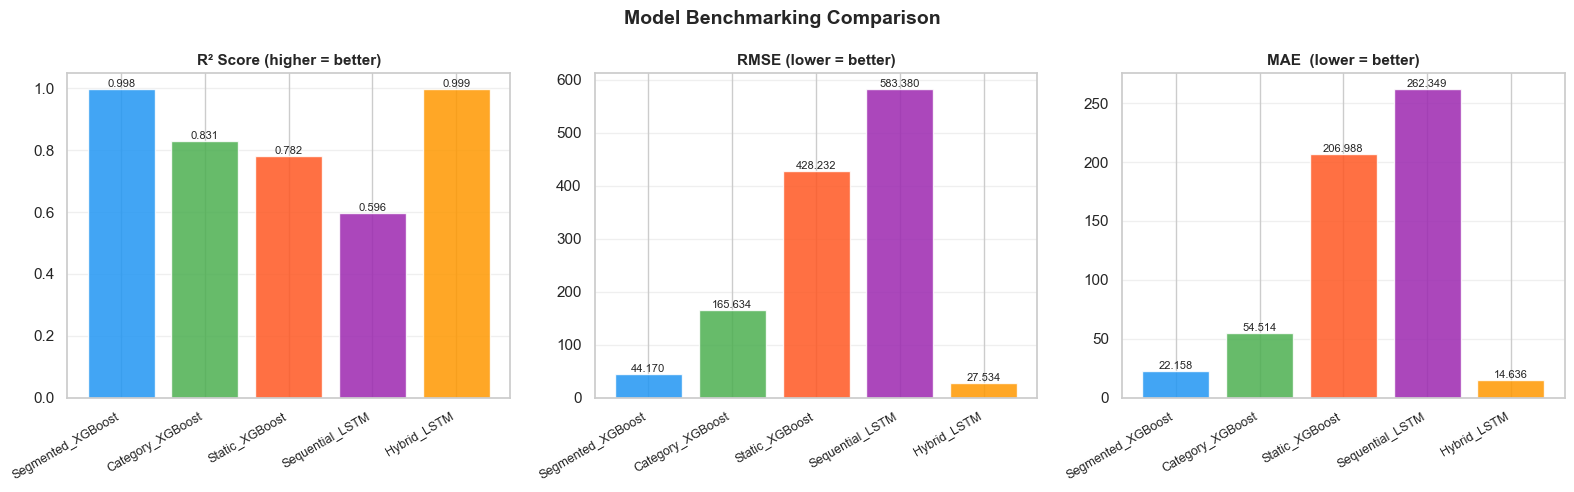

In [87]:
# ── Safe Benchmarking — handles missing variables gracefully ──────────

import pandas as pd
import numpy as np

# Helper to safely get variable value or return None
def safe_get(var_name):
    try:
        return eval(var_name)
    except NameError:
        print(f"Warning: '{var_name}' not found — setting to None")
        return None

# ── Build benchmark_metrics safely ───────────────────────────────────
benchmark_metrics = {}

# Segmented XGBoost
if all(v is not None for v in [safe_get('seg_rmse'), 
                                safe_get('seg_mae'), 
                                safe_get('seg_r2')]):
    benchmark_metrics['Segmented_XGBoost'] = {
        'RMSE': seg_rmse,
        'MAE' : seg_mae,
        'R2'  : seg_r2
    }

# Category XGBoost
if all(v is not None for v in [safe_get('cat_rmse'), 
                                safe_get('cat_mae'), 
                                safe_get('cat_r2')]):
    benchmark_metrics['Category_XGBoost'] = {
        'RMSE': cat_rmse,
        'MAE' : cat_mae,
        'R2'  : cat_r2
    }

# Static XGBoost
if all(v is not None for v in [safe_get('rmse'), 
                                safe_get('mae'), 
                                safe_get('r2')]):
    benchmark_metrics['Static_XGBoost'] = {
        'RMSE': rmse,
        'MAE' : mae,
        'R2'  : r2
    }

# Sequential LSTM
if all(v is not None for v in [safe_get('rmse_lstm_seq'), 
                                safe_get('mae_lstm_seq'), 
                                safe_get('r2_lstm_seq')]):
    benchmark_metrics['Sequential_LSTM'] = {
        'RMSE': rmse_lstm_seq,
        'MAE' : mae_lstm_seq,
        'R2'  : r2_lstm_seq
    }

# Hybrid LSTM
if all(v is not None for v in [safe_get('lstm_rmse'), 
                                safe_get('lstm_mae'), 
                                safe_get('lstm_r2')]):
    benchmark_metrics['Hybrid_LSTM'] = {
        'RMSE': lstm_rmse,
        'MAE' : lstm_mae,
        'R2'  : lstm_r2
    }

# ── Build DataFrame ───────────────────────────────────────────────────
benchmark_df = pd.DataFrame(benchmark_metrics).T
benchmark_df.index.name = 'Model'
benchmark_df = benchmark_df.round(4)

print("\n── Model Benchmarking Results ───────────────")
print(benchmark_df.to_string())

# ── Visual Plot ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Benchmarking Comparison', 
             fontsize=14, fontweight='bold')

colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']
models = benchmark_df.index.tolist()
x      = np.arange(len(models))

for ax, (metric, title) in zip(axes, [('R2',   'R² Score (higher = better)'),
                                       ('RMSE', 'RMSE (lower = better)'),
                                       ('MAE',  'MAE  (lower = better)')]):
    if metric not in benchmark_df.columns:
        continue
    bars = ax.bar(x, benchmark_df[metric], color=colors[:len(models)], 
                  alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


── Hybrid LSTM vs Sequential LSTM ───────────
                     RMSE       MAE      R2
Model                                      
Hybrid_LSTM       27.5343   14.6361  0.9990
Sequential_LSTM  583.3796  262.3485  0.5956


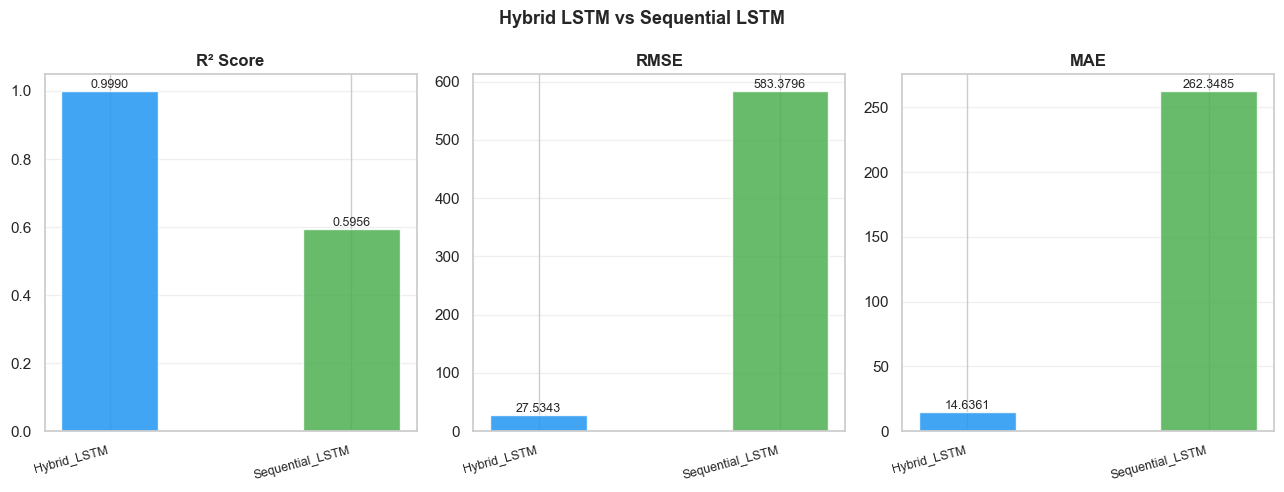

In [88]:
# Subset comparison: Only Hybrid LSTM and Sequential LSTM

available = [m for m in ['Hybrid_LSTM', 'Sequential_LSTM'] 
             if m in benchmark_df.index]

if len(available) == 0:
    print("Neither model found in benchmark_df.")
    print(f"Available models: {benchmark_df.index.tolist()}")

else:
    benchmark_subset_df = benchmark_df.loc[available]
    
    print("\n── Hybrid LSTM vs Sequential LSTM ───────────")
    print(benchmark_subset_df.to_string())

    # ── Visual comparison ─────────────────────────────────────────────
    import matplotlib.pyplot as plt
    import numpy as np

    fig, axes = plt.subplots(1, 3, figsize=(13, 5))
    fig.suptitle('Hybrid LSTM vs Sequential LSTM', 
                 fontsize=13, fontweight='bold')

    metrics = [('R2',   'R² Score',  ['#2196F3', '#4CAF50']),
               ('RMSE', 'RMSE',      ['#2196F3', '#4CAF50']),
               ('MAE',  'MAE',       ['#2196F3', '#4CAF50'])]

    x     = np.arange(len(available))
    width = 0.4

    for ax, (col, title, colors) in zip(axes, metrics):
        if col not in benchmark_subset_df.columns:
            continue
        bars = ax.bar(x, benchmark_subset_df[col], 
                      width  = width,
                      color  = colors[:len(available)],
                      alpha  = 0.85,
                      edgecolor = 'white')
        ax.set_title(title, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(available, rotation=15, ha='right', fontsize=9)
        ax.grid(axis='y', alpha=0.3)

        # Value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

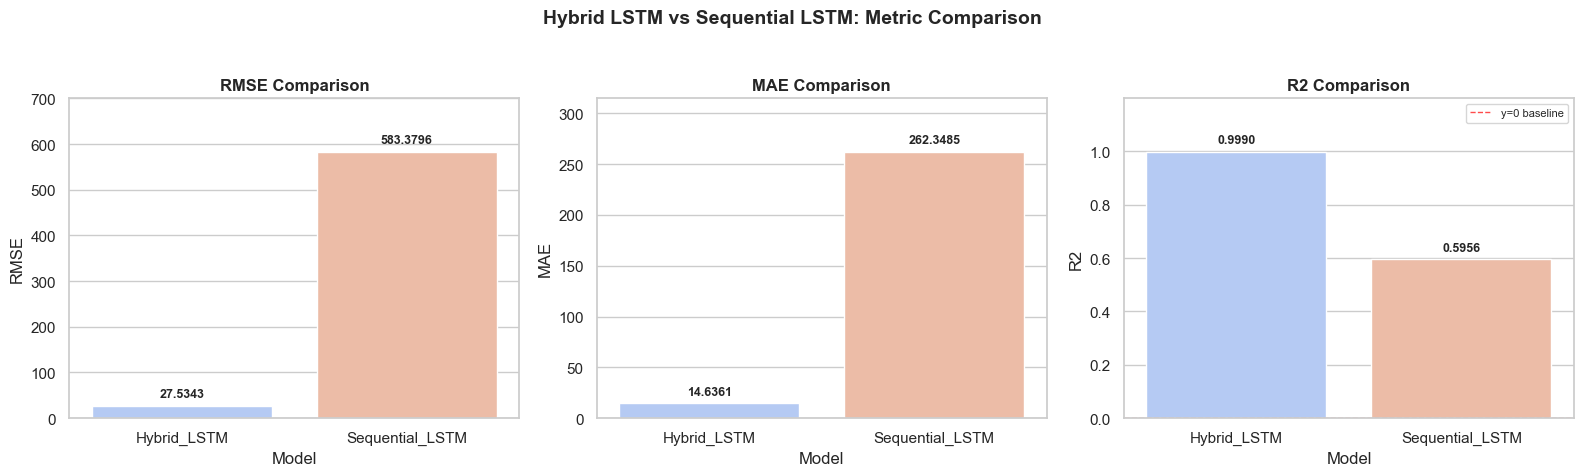

In [89]:
# Visualising Hybrid LSTM and Sequential LSTM

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics   = ['RMSE', 'MAE', 'R2']

for i, metric in enumerate(metrics):
    values = benchmark_subset_df[metric].values

    sns.barplot(
        ax      = axes[i],
        x       = benchmark_subset_df.index,
        y       = values,
        hue     = benchmark_subset_df.index,
        palette = "coolwarm",
        legend  = False
    )

    axes[i].set_title(f'{metric} Comparison', fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel('Model')

    # Fix ylim — handle negative values (e.g. R² = -1.256)
    min_val = min(values.min(), 0)
    max_val = values.max()
    axes[i].set_ylim(min_val * 1.3 if min_val < 0 else 0,
                     max_val * 1.2)

    # Add value labels on each bar
    for bar in axes[i].patches:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width() / 2.,
            height + (max_val * 0.02),
            f'{height:.4f}',
            ha       = 'center',
            va       = 'bottom',
            fontsize = 9,
            fontweight = 'bold'
        )

    # Add horizontal line at 0 for R² chart
    if metric == 'R2':
        axes[i].axhline(y=0, color='red', linestyle='--', 
                        linewidth=1, alpha=0.7, label='y=0 baseline')
        axes[i].legend(fontsize=8)

plt.suptitle('Hybrid LSTM vs Sequential LSTM: Metric Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# LSTM Loss and Validation plot

def plot_lstm_training(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
    plt.title('LSTM Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Call after model training
plot_lstm_training(history)

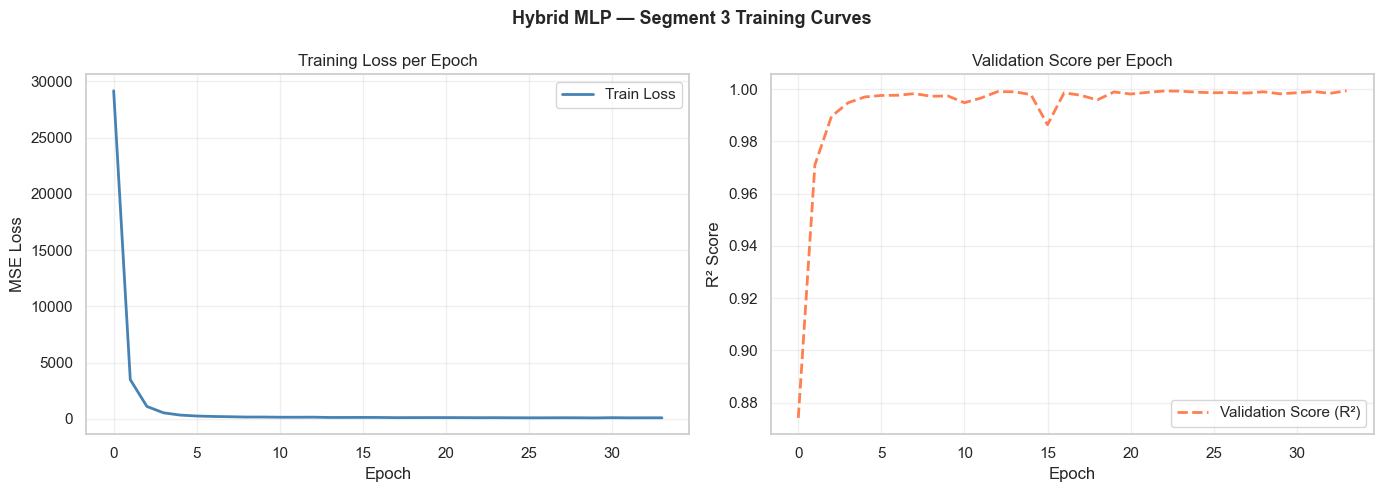


Training Summary:
  Total epochs run  : 34
  Initial loss      : 29164.914039
  Final loss        : 89.050403
  Best loss         : 80.221035


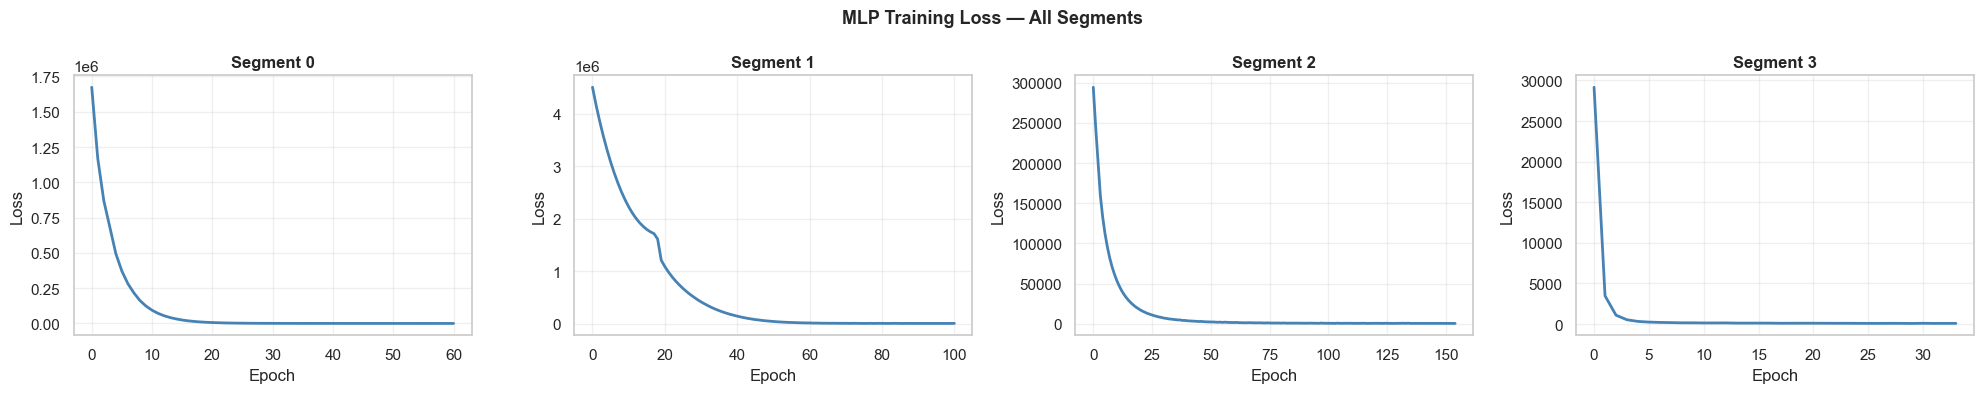

In [91]:
# MLP Loss and Validation plot (replaces LSTM history plot)

import matplotlib.pyplot as plt
import numpy as np

def plot_mlp_training(model, model_name='MLP'):
    """
    Plots training loss curve from sklearn MLPRegressor.
    Uses loss_curve_ for train and validation_scores_ for validation.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} Training Curves', 
                 fontsize=13, fontweight='bold')

    # ── Train Loss Curve ──────────────────────────────────────────────
    if hasattr(model, 'loss_curve_'):
        axes[0].plot(model.loss_curve_, 
                     label='Train Loss', 
                     linewidth=2, 
                     color='steelblue')
        axes[0].set_title('Training Loss per Epoch')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('MSE Loss')
        axes[0].legend()
        axes[0].grid(alpha=0.3)
    else:
        axes[0].text(0.5, 0.5, 'No loss curve available',
                     ha='center', va='center',
                     transform=axes[0].transAxes)

    # ── Validation Score Curve ────────────────────────────────────────
    if hasattr(model, 'validation_scores_') and model.validation_scores_:
        axes[1].plot(model.validation_scores_,
                     label='Validation Score (R²)',
                     linewidth=2,
                     linestyle='--',
                     color='coral')
        axes[1].set_title('Validation Score per Epoch')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('R² Score')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'No validation curve available',
                     ha='center', va='center',
                     transform=axes[1].transAxes)

    plt.tight_layout()
    plt.show()

    # Print summary
    if hasattr(model, 'loss_curve_'):
        print(f"\nTraining Summary:")
        print(f"  Total epochs run  : {len(model.loss_curve_)}")
        print(f"  Initial loss      : {model.loss_curve_[0]:.6f}")
        print(f"  Final loss        : {model.loss_curve_[-1]:.6f}")
        print(f"  Best loss         : {min(model.loss_curve_):.6f}")


# ── Option 1: Plot last trained segment model ─────────────────────────
# Get the last segment's MLP model
last_seg = sorted(segment_models.keys())[-1]
last_mlp = segment_models[last_seg]['MLP']
plot_mlp_training(last_mlp, model_name=f'Hybrid MLP — Segment {last_seg}')


# ── Option 2: Plot all segments in one figure ─────────────────────────
fig, axes = plt.subplots(1, len(segment_models), 
                          figsize=(5 * len(segment_models), 4))

# Handle case where only 1 segment exists
if len(segment_models) == 1:
    axes = [axes]

for ax, (seg, models) in zip(axes, sorted(segment_models.items())):
    mlp = models['MLP']
    if hasattr(mlp, 'loss_curve_'):
        ax.plot(mlp.loss_curve_, linewidth=2, color='steelblue')
        ax.set_title(f'Segment {seg}', fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No curve', ha='center', 
                va='center', transform=ax.transAxes)

fig.suptitle('MLP Training Loss — All Segments', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Model Evaluation


── Final Benchmark Comparison Across All Models ─────────────
                       RMSE       MAE      R2
Segmented_XGBoost   44.1701   22.1584  0.9983
Category_XGBoost   165.6340   54.5137  0.8311
Static_XGBoost     428.2322  206.9885  0.7821
Sequential_LSTM    583.3796  262.3485  0.5956
Hybrid_LSTM         27.5343   14.6361  0.9990


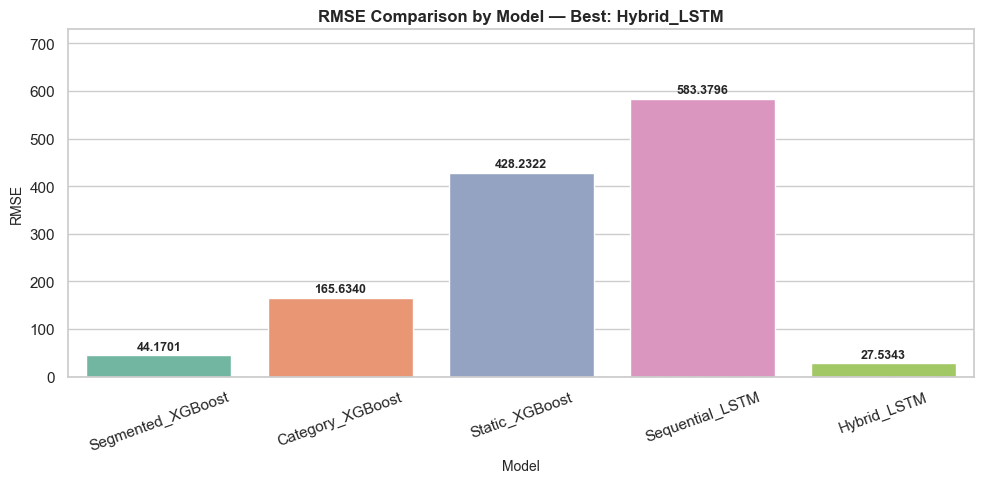

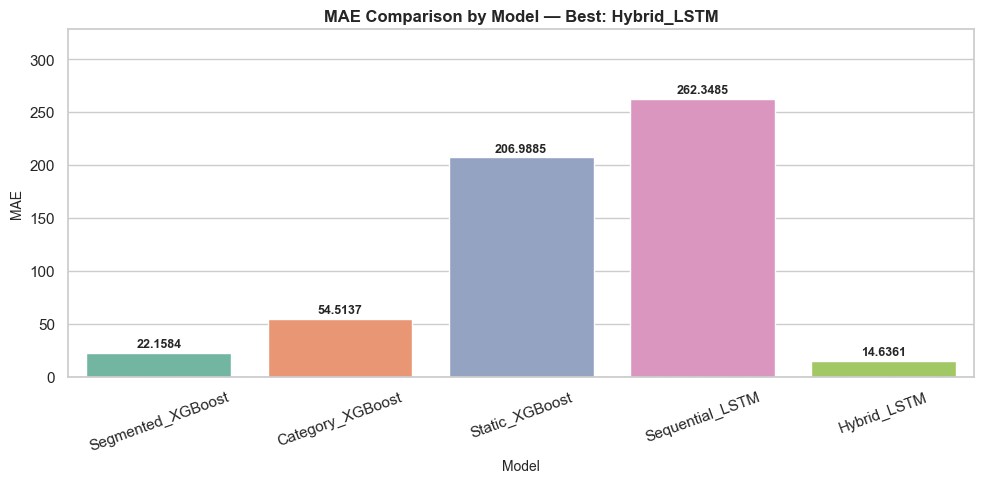

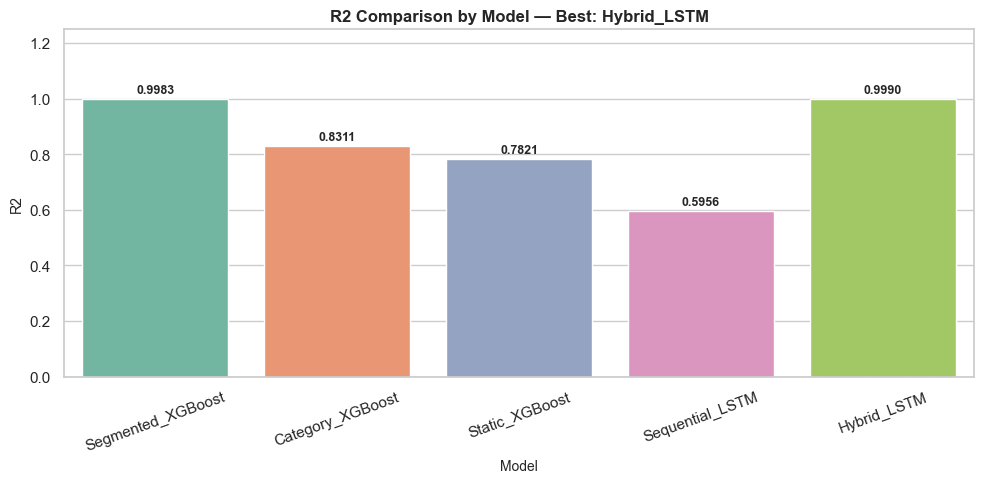

In [92]:
# Final benchmarking across all models

benchmark_df = pd.DataFrame(benchmark_metrics).T
print("\n── Final Benchmark Comparison Across All Models ─────────────")
print(benchmark_df.round(4).to_string())

# ── Final Benchmark Visualisations ───────────────────────────────────
benchmark_plot_df = (pd.DataFrame(benchmark_metrics).T
                       .reset_index()
                       .rename(columns={"index": "Model"}))

# Melt for seaborn
comparison_df = benchmark_plot_df.melt(
    id_vars  = "Model",
    var_name = "Metric",
    value_name = "Score"
)
comparison_df['Score'] = comparison_df['Score'].astype(float)

sns.set(style="whitegrid")

for metric in ['RMSE', 'MAE', 'R2']:

    if metric not in comparison_df['Metric'].values:
        continue

    metric_data = comparison_df[comparison_df['Metric'] == metric].copy()

    plt.figure(figsize=(10, 5))

    ax = sns.barplot(
        data    = metric_data,
        x       = "Model",
        y       = "Score",
        hue     = "Model",
        palette = "Set2",
        legend  = False
    )

    # Dynamic y limits — handles negative R²
    min_val = metric_data['Score'].min()
    max_val = metric_data['Score'].max()
    ax.set_ylim(min_val * 1.3 if min_val < 0 else 0,
                max_val * 1.25)

    # Zero baseline
    ax.axhline(0, color='black', linestyle='--',
               linewidth=0.8, alpha=0.6)

    # Value labels on bars
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            height + (max_val * 0.01),
            f'{height:.4f}',
            ha         = 'center',
            va         = 'bottom',
            fontsize   = 9,
            fontweight = 'bold'
        )

    # Best model annotation
    if metric == 'R2':
        best_model = metric_data.loc[metric_data['Score'].idxmax(), 'Model']
        note = f"Best: {best_model}"
    else:
        best_model = metric_data.loc[metric_data['Score'].idxmin(), 'Model']
        note = f"Best: {best_model}"

    ax.set_title(f"{metric} Comparison by Model — {note}",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Model", fontsize=10)
    ax.set_ylabel(metric,  fontsize=10)
    ax.tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()


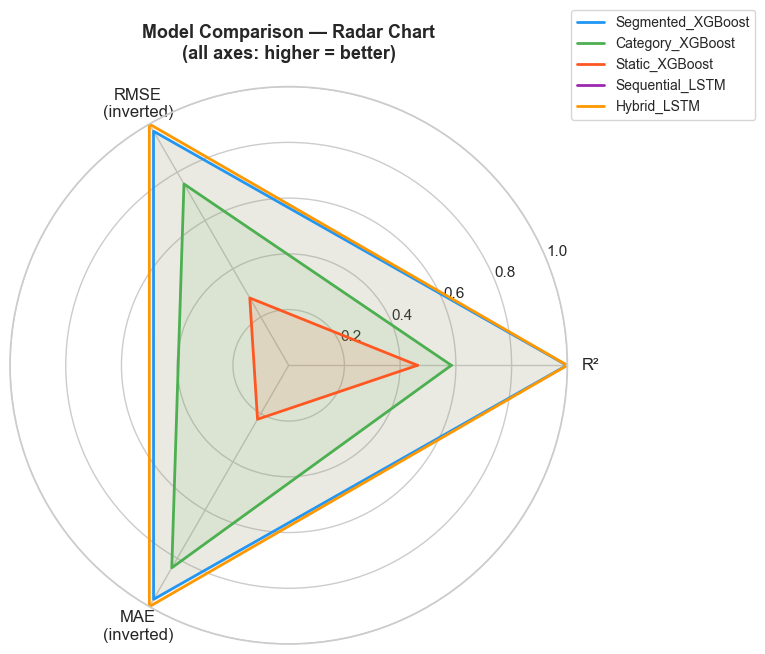

In [94]:
# Final benchmarking across all models

def plot_radar(benchmark_df):
    # Normalise all metrics 0-1 for radar
    # For RMSE and MAE: invert so higher = better on all axes
    df = benchmark_df.copy().astype(float)
    
    df_norm = df.copy()
    df_norm['R2']   = (df['R2']   - df['R2'].min())   / (df['R2'].max()   - df['R2'].min() + 1e-9)
    df_norm['RMSE'] = 1 - (df['RMSE'] - df['RMSE'].min()) / (df['RMSE'].max() - df['RMSE'].min() + 1e-9)
    df_norm['MAE']  = 1 - (df['MAE']  - df['MAE'].min())  / (df['MAE'].max()  - df['MAE'].min()  + 1e-9)

    categories = ['R²', 'RMSE\n(inverted)', 'MAE\n(inverted)']
    N          = len(categories)
    angles     = [n / float(N) * 2 * np.pi for n in range(N)]
    angles    += angles[:1]  # close the polygon

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colors  = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']

    for i, (model, row) in enumerate(df_norm.iterrows()):
        values  = row[['R2', 'RMSE', 'MAE']].tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2,
                color=colors[i % len(colors)], label=model)
        ax.fill(angles, values, alpha=0.1,
                color=colors[i % len(colors)])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_title('Model Comparison — Radar Chart\n(all axes: higher = better)',
                 fontsize=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
    plt.tight_layout()
    plt.show()

plot_radar(benchmark_df)